In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


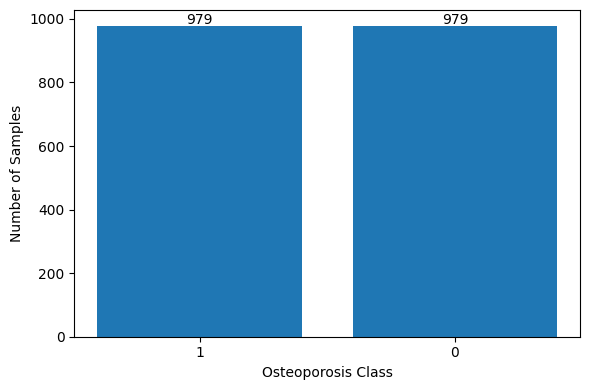

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

file_path = "/content/drive/MyDrive/Osteoporosis_project/lifestyle/osteoporosis.csv"
df = pd.read_csv(file_path)


class_counts = df['Osteoporosis'].value_counts()
plt.figure(figsize=(6,4))
plt.bar(class_counts.index.astype(str), class_counts.values)
plt.xlabel("Osteoporosis Class")
plt.ylabel("Number of Samples")



for i, v in enumerate(class_counts.values):
    plt.text(i, v + 5, str(v), ha='center')

plt.tight_layout()
plt.show()


In [ ]:

import pandas as pd

file_path = "/content/drive/MyDrive/Osteoporosis_project/lifestyle/osteoporosis.csv"
df = pd.read_csv(file_path)


print("Dataset shape:", df.shape)
print("\nFeature summary:\n")
print(df.info())
print("\nFirst 5 rows:\n", df.head())


print("\nMissing values per column:\n", df.isnull().sum())


print("\nClass distribution (Osteoporosis outcome):")
print(df['Osteoporosis'].value_counts())
print("\nClass distribution (percentage):")
print(df['Osteoporosis'].value_counts(normalize=True) * 100)


Dataset shape: (1958, 16)

Feature summary:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1958 entries, 0 to 1957
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Id                   1958 non-null   int64 
 1   Age                  1958 non-null   int64 
 2   Gender               1958 non-null   object
 3   Hormonal Changes     1958 non-null   object
 4   Family History       1958 non-null   object
 5   Race/Ethnicity       1958 non-null   object
 6   Body Weight          1958 non-null   object
 7   Calcium Intake       1958 non-null   object
 8   Vitamin D Intake     1958 non-null   object
 9   Physical Activity    1958 non-null   object
 10  Smoking              1958 non-null   object
 11  Alcohol Consumption  970 non-null    object
 12  Medical Conditions   1311 non-null   object
 13  Medications          973 non-null    object
 14  Prior Fractures      1958 non-null   object
 15  Osteoporos

# data preprocessing

In [ ]:
import pandas as pd
import numpy as np
import os
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

save_dir = "/content/drive/MyDrive/Osteoporosis_project/lifestyle"
os.makedirs(save_dir, exist_ok=True)


def preprocess_base(df):
    df = df.copy()


    if "Id" in df.columns:
        df.drop(columns=["Id"], inplace=True)


    for col in df.columns:
        if df[col].isnull().sum() > 0:
            df[col + "_missing"] = df[col].isnull().astype(int)

    cat_cols = df.select_dtypes(include=["object"]).columns
    df[cat_cols] = df[cat_cols].fillna("Unknown")

    return df



def build_ohe_preprocessor(df):
    numeric_features = ["Age"]
    categorical_features = df.select_dtypes(include=["object"]).columns.tolist()
    categorical_features.remove("Osteoporosis")  # remove target

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), numeric_features),
            ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
        ],
        remainder="passthrough"
    )

    return preprocessor




def label_encode_dataframe(df):
    df = df.copy()
    cat_cols = df.select_dtypes(include=["object"]).columns.tolist()

    le_dict = {}

    for col in cat_cols:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])
        le_dict[col] = le

    return df, le_dict




def save_preprocessed(df_clean, df_label_encoded, le_dict):

    df_clean.to_csv(os.path.join(save_dir, "df_clean_ohe.csv"), index=False)


    df_label_encoded.to_csv(os.path.join(save_dir, "df_label_encoded.csv"), index=False)


    import pickle
    with open(os.path.join(save_dir, "label_encoders.pkl"), "wb") as f:
        pickle.dump(le_dict, f)

    print("Saved df_clean_ohe.csv, df_label_encoded.csv, and label_encoders.pkl")


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
import joblib
import os


path = "/content/drive/MyDrive/Osteoporosis_project/lifestyle/osteoporosis.csv"
df = pd.read_csv(path)


if "Id" in df.columns:
    df = df.drop(columns=["Id"])

print("Columns after removing Id:", df.columns.tolist())


X = df.drop(columns=["Osteoporosis"])
y = df["Osteoporosis"]


numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()

print("Numeric:", numeric_cols)
print("Categorical:", categorical_cols)



numeric_pipeline = SimpleImputer(strategy="median")

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_pipeline, numeric_cols),
    ("cat", categorical_pipeline, categorical_cols)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed X_train shape:", X_train_processed.shape)
print("Processed X_test shape:", X_test_processed.shape)


save_dir = "/content/drive/MyDrive/Osteoporosis_project/lifestyle/"
os.makedirs(save_dir, exist_ok=True)

pd.DataFrame(X_train_processed.toarray() if hasattr(X_train_processed, "toarray") else X_train_processed)\
  .to_csv(save_dir + "X_train_preprocessed.csv", index=False)

pd.DataFrame(X_test_processed.toarray() if hasattr(X_test_processed, "toarray") else X_test_processed)\
  .to_csv(save_dir + "X_test_preprocessed.csv", index=False)

y_train.to_csv(save_dir + "y_train.csv", index=False)
y_test.to_csv(save_dir + "y_test.csv", index=False)

joblib.dump(preprocessor, save_dir + "preprocessing_pipeline.pkl")

print("Saved corrected files without Id column!")


Columns after removing Id: ['Age', 'Gender', 'Hormonal Changes', 'Family History', 'Race/Ethnicity', 'Body Weight', 'Calcium Intake', 'Vitamin D Intake', 'Physical Activity', 'Smoking', 'Alcohol Consumption', 'Medical Conditions', 'Medications', 'Prior Fractures', 'Osteoporosis']
Numeric: ['Age']
Categorical: ['Gender', 'Hormonal Changes', 'Family History', 'Race/Ethnicity', 'Body Weight', 'Calcium Intake', 'Vitamin D Intake', 'Physical Activity', 'Smoking', 'Alcohol Consumption', 'Medical Conditions', 'Medications', 'Prior Fractures']
Processed X_train shape: (1566, 26)
Processed X_test shape: (392, 26)
Saved corrected files without Id column!


# logistic Regression

In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns

base = "/content/drive/MyDrive/Osteoporosis_project/lifestyle/"

X_train = pd.read_csv(base + "X_train_preprocessed.csv")
X_test = pd.read_csv(base + "X_test_preprocessed.csv")
y_train = pd.read_csv(base + "y_train.csv")
y_test = pd.read_csv(base + "y_test.csv")

y_train = y_train.values.ravel()
y_test = y_test.values.ravel()

print("Shapes:", X_train.shape, X_test.shape)


logreg = LogisticRegression(
    max_iter=500,
    class_weight="balanced",
    solver="lbfgs"
)

logreg.fit(X_train, y_train)


train_preds = logreg.predict(X_train)
test_preds = logreg.predict(X_test)

train_probs = logreg.predict_proba(X_train)[:, 1]
test_probs = logreg.predict_proba(X_test)[:, 1]

metrics = {
    "Train Accuracy": accuracy_score(y_train, train_preds),
    "Test Accuracy": accuracy_score(y_test, test_preds),
    "Train F1": f1_score(y_train, train_preds),
    "Test F1": f1_score(y_test, test_preds),
    "Train AUC": roc_auc_score(y_train, train_probs),
    "Test AUC": roc_auc_score(y_test, test_probs)
}

metrics


Shapes: (1566, 26) (392, 26)


{'Train Accuracy': 0.830779054916986,
 'Test Accuracy': 0.7933673469387755,
 'Train F1': 0.8236859614105123,
 'Test F1': 0.7804878048780488,
 'Train AUC': np.float64(0.9117199949762596),
 'Test AUC': np.float64(0.8758329862557268)}

In [ ]:
import joblib
import os


save_dir = "/content/drive/MyDrive/Osteoporosis_project/lifestyle/"
os.makedirs(save_dir, exist_ok=True)


logreg_path = os.path.join(save_dir, "logistic_regression_model.pkl")
joblib.dump(logreg, logreg_path)

print(f"Logistic Regression model saved at: {logreg_path}")


Logistic Regression model saved at: /content/drive/MyDrive/Osteoporosis_project/lifestyle/logistic_regression_model.pkl


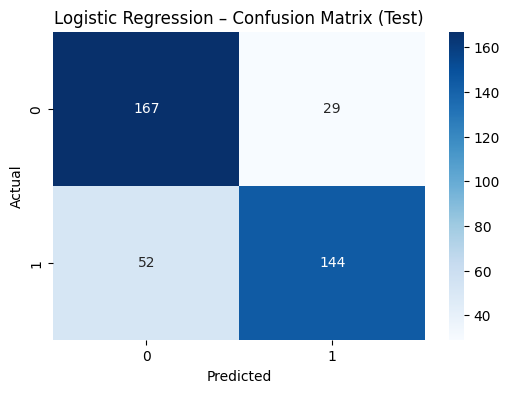

In [ ]:
cm = confusion_matrix(y_test, test_preds)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Logistic Regression – Confusion Matrix (Test)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [ ]:
print(classification_report(y_test, test_preds))


              precision    recall  f1-score   support

           0       0.76      0.85      0.80       196
           1       0.83      0.73      0.78       196

    accuracy                           0.79       392
   macro avg       0.80      0.79      0.79       392
weighted avg       0.80      0.79      0.79       392



# Random forest

Random Forest metrics:
 {'Train Accuracy': 0.8825031928480205, 'Test Accuracy': 0.8392857142857143, 'Train F1': 0.8670520231213873, 'Test F1': 0.8141592920353983, 'Train AUC': np.float64(0.976858987846789), 'Test AUC': np.float64(0.8811953352769679)}


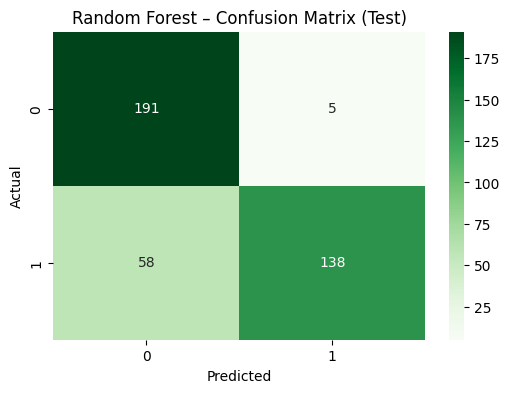

Random Forest model saved at: /content/drive/MyDrive/Osteoporosis_project/lifestyle/random_forest_model.pkl


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os


base = "/content/drive/MyDrive/Osteoporosis_project/lifestyle/"

X_train = pd.read_csv(base + "X_train_preprocessed.csv")
X_test = pd.read_csv(base + "X_test_preprocessed.csv")
y_train = pd.read_csv(base + "y_train.csv").values.ravel()
y_test = pd.read_csv(base + "y_test.csv").values.ravel()


rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=7,
    min_samples_leaf=5,
    max_features="sqrt",
    random_state=42,
    class_weight="balanced"
)


rf.fit(X_train, y_train)


train_preds = rf.predict(X_train)
test_preds = rf.predict(X_test)

train_probs = rf.predict_proba(X_train)[:, 1]
test_probs = rf.predict_proba(X_test)[:, 1]


metrics_rf = {
    "Train Accuracy": accuracy_score(y_train, train_preds),
    "Test Accuracy": accuracy_score(y_test, test_preds),
    "Train F1": f1_score(y_train, train_preds),
    "Test F1": f1_score(y_test, test_preds),
    "Train AUC": roc_auc_score(y_train, train_probs),
    "Test AUC": roc_auc_score(y_test, test_probs)
}

print("Random Forest metrics:\n", metrics_rf)


cm = confusion_matrix(y_test, test_preds)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens")
plt.title("Random Forest – Confusion Matrix (Test)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


rf_path = os.path.join(base, "random_forest_model.pkl")
joblib.dump(rf, rf_path)
print(f"Random Forest model saved at: {rf_path}")


# gradient booster

In [ ]:
import pandas as pd
import os

save_dir = "/content/drive/MyDrive/Osteoporosis_project/lifestyle/"

X_train = pd.read_csv(os.path.join(save_dir, "X_train_preprocessed.csv"))
X_test  = pd.read_csv(os.path.join(save_dir, "X_test_preprocessed.csv"))

y_train = pd.read_csv(os.path.join(save_dir, "y_train.csv")).values.ravel()
y_test  = pd.read_csv(os.path.join(save_dir, "y_test.csv")).values.ravel()

print("Shapes:", X_train.shape, X_test.shape, y_train.shape, y_test.shape)


Shapes: (1566, 26) (392, 26) (1566,) (392,)


In [ ]:
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report


In [ ]:

gb = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.01,
    max_depth=3
)

gb.fit(X_train, y_train)

gb_preds = gb.predict(X_test)
gb_probs = gb.predict_proba(X_test)[:, 1]

print("GRADIENT BOOSTING RESULTS ")
print("Accuracy:", accuracy_score(y_test, gb_preds))
print("F1-Score:", f1_score(y_test, gb_preds))
print("AUC:", roc_auc_score(y_test, gb_probs))
print("\nClassification Report:\n", classification_report(y_test, gb_preds))


GRADIENT BOOSTING RESULTS 
Accuracy: 0.8852040816326531
F1-Score: 0.8703170028818443
AUC: 0.8899807371928363

Classification Report:
               precision    recall  f1-score   support

           0       0.81      1.00      0.90       196
           1       1.00      0.77      0.87       196

    accuracy                           0.89       392
   macro avg       0.91      0.89      0.88       392
weighted avg       0.91      0.89      0.88       392



# tuned gradient booster

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import pandas as pd
import os

save_dir = "/content/drive/MyDrive/Osteoporosis_project/lifestyle/"

# Load data
X_train = pd.read_csv(os.path.join(save_dir, "X_train_preprocessed.csv"))
X_test  = pd.read_csv(os.path.join(save_dir, "X_test_preprocessed.csv"))
y_train = pd.read_csv(os.path.join(save_dir, "y_train.csv")).values.ravel()
y_test  = pd.read_csv(os.path.join(save_dir, "y_test.csv")).values.ravel()

param_grid = {
    "n_estimators": [200, 300, 400, 500],
    "learning_rate": [0.01, 0.02, 0.05],
    "max_depth": [2, 3, 4]
}

gb = GradientBoostingClassifier()

grid = GridSearchCV(
    gb,
    param_grid,
    scoring="f1",
    cv=3,
    n_jobs=-1,
    verbose=2
)

grid.fit(X_train, y_train)

print(" Best Parameters:", grid.best_params_)
best_gb = grid.best_estimator_

# Evaluate best model
preds = best_gb.predict(X_test)
probs = best_gb.predict_proba(X_test)[:, 1]

print(" TUNED GRADIENT BOOSTING RESULTS ")
print("Accuracy:", accuracy_score(y_test, preds))
print("F1-Score:", f1_score(y_test, preds))
print("AUC:", roc_auc_score(y_test, probs))
print("\nClassification Report:\n", classification_report(y_test, preds))


Fitting 3 folds for each of 36 candidates, totalling 108 fits
 Best Parameters: {'learning_rate': 0.02, 'max_depth': 2, 'n_estimators': 500}
 TUNED GRADIENT BOOSTING RESULTS 
Accuracy: 0.8852040816326531
F1-Score: 0.8703170028818443
AUC: 0.8924796959600166

Classification Report:
               precision    recall  f1-score   support

           0       0.81      1.00      0.90       196
           1       1.00      0.77      0.87       196

    accuracy                           0.89       392
   macro avg       0.91      0.89      0.88       392
weighted avg       0.91      0.89      0.88       392



In [ ]:
import joblib
import os


save_dir = "/content/drive/MyDrive/Osteoporosis_project/lifestyle/"
os.makedirs(save_dir, exist_ok=True)


gb_path = os.path.join(save_dir, "gradient_boosting_tuned.pkl")

joblib.dump(best_gb, gb_path)
print(f" Tuned Gradient Boosting model saved at: {gb_path}")


 Tuned Gradient Boosting model saved at: /content/drive/MyDrive/Osteoporosis_project/lifestyle/gradient_boosting_tuned.pkl


# xgboost baseline

XGBoost metrics:
 {'Train Accuracy': 0.9157088122605364, 'Test Accuracy': 0.8775510204081632, 'Train F1': 0.9082058414464534, 'Test F1': 0.8620689655172413, 'Train AUC': np.float64(0.9571293890446575), 'Test AUC': np.float64(0.8903581840899625)}


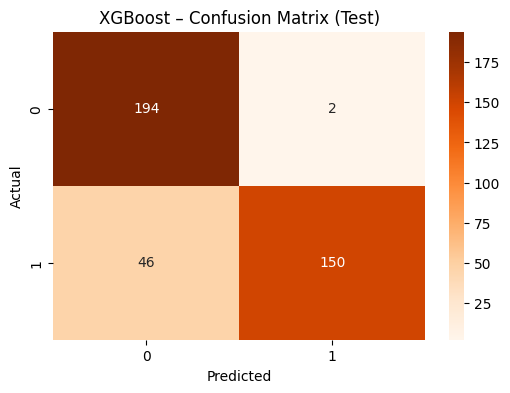

XGBoost model saved at: /content/drive/MyDrive/Osteoporosis_project/lifestyle/xgboost_model.pkl


In [ ]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os


base = "/content/drive/MyDrive/Osteoporosis_project/lifestyle/"

X_train = pd.read_csv(base + "X_train_preprocessed.csv")
X_test = pd.read_csv(base + "X_test_preprocessed.csv")
y_train = pd.read_csv(base + "y_train.csv").values.ravel()
y_test = pd.read_csv(base + "y_test.csv").values.ravel()

xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=3,
    learning_rate=0.03,
    subsample=0.9,
    colsample_bytree=0.8,
    min_child_weight=5,
    eval_metric="auc",
    random_state=42
)



xgb_model.fit(X_train, y_train)


train_preds = xgb_model.predict(X_train)
test_preds = xgb_model.predict(X_test)

train_probs = xgb_model.predict_proba(X_train)[:, 1]
test_probs = xgb_model.predict_proba(X_test)[:, 1]

-
metrics_xgb = {
    "Train Accuracy": accuracy_score(y_train, train_preds),
    "Test Accuracy": accuracy_score(y_test, test_preds),
    "Train F1": f1_score(y_train, train_preds),
    "Test F1": f1_score(y_test, test_preds),
    "Train AUC": roc_auc_score(y_train, train_probs),
    "Test AUC": roc_auc_score(y_test, test_probs)
}

print("XGBoost metrics:\n", metrics_xgb)


cm = confusion_matrix(y_test, test_preds)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges")
plt.title("XGBoost – Confusion Matrix (Test)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


xgb_path = os.path.join(base, "xgboost_model.pkl")
joblib.dump(xgb_model, xgb_path)
print(f"XGBoost model saved at: {xgb_path}")


# tuned xgboost

In [ ]:
import pandas as pd
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, classification_report
import joblib
import os


base = "/content/drive/MyDrive/Osteoporosis_project/lifestyle/"

X_train = pd.read_csv(base + "X_train_preprocessed.csv")
X_test = pd.read_csv(base + "X_test_preprocessed.csv")
y_train = pd.read_csv(base + "y_train.csv").values.ravel()
y_test = pd.read_csv(base + "y_test.csv").values.ravel()


param_grid = {
    'max_depth': [3, 5, 7],
    'min_child_weight': [1, 3, 5],
    'reg_alpha': [0, 0.1, 1],
    'reg_lambda': [0, 0.1, 1]
}


xgb_model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.03,
    subsample=0.9,
    colsample_bytree=0.8,
    eval_metric='auc',
    use_label_encoder=False,
    random_state=42
)

grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    scoring='accuracy',
    cv=5,
    n_jobs=-1,
    verbose=2
)


grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)


best_model = grid_search.best_estimator_

train_preds = best_model.predict(X_train)
test_preds = best_model.predict(X_test)

train_probs = best_model.predict_proba(X_train)[:, 1]
test_probs = best_model.predict_proba(X_test)[:, 1]

metrics_xgb = {
    "Train Accuracy": accuracy_score(y_train, train_preds),
    "Test Accuracy": accuracy_score(y_test, test_preds),
    "Train F1": f1_score(y_train, train_preds),
    "Test F1": f1_score(y_test, test_preds),
    "Train AUC": roc_auc_score(y_train, train_probs),
    "Test AUC": roc_auc_score(y_test, test_probs)
}

print("XGBoost metrics:\n", metrics_xgb)

print("\nClassification Report (Test):")
print(classification_report(y_test, test_preds))


xgb_path = os.path.join(base, "xgboost_model_tuned.pkl")
joblib.dump(best_model, xgb_path)
print(f"XGBoost model saved at: {xgb_path}")


Fitting 5 folds for each of 81 candidates, totalling 405 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [14:30:42] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best Parameters: {'max_depth': 3, 'min_child_weight': 1, 'reg_alpha': 0.1, 'reg_lambda': 1}
XGBoost metrics:
 {'Train Accuracy': 0.9240102171136654, 'Test Accuracy': 0.8852040816326531, 'Train F1': 0.9178743961352657, 'Test F1': 0.8710601719197708, 'Train AUC': np.float64(0.9731596880713893), 'Test AUC': np.float64(0.8846053727613493)}

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.82      0.99      0.90       196
           1       0.99      0.78      0.87       196

    accuracy                           0.89       392
   macro avg       0.90      0.89      0.88       392
weighted avg       0.90      0.89      0.88       392

XGBoost model saved at: /content/drive/MyDrive/Osteoporosis_project/lifestyle/xgboost_model_tuned.pkl


# lightgbm

[LightGBM] [Info] Number of positive: 783, number of negative: 783
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000125 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 120
[LightGBM] [Info] Number of data points in the train set: 1566, number of used features: 24
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive 

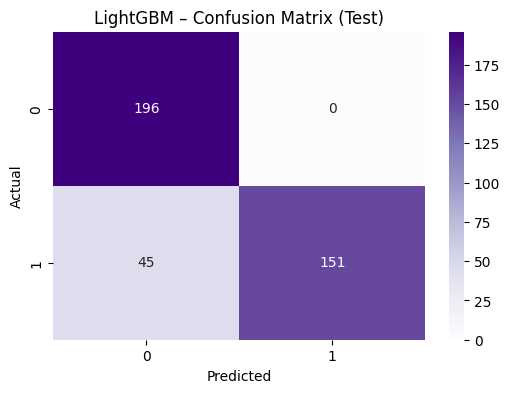

LightGBM model saved at: /content/drive/MyDrive/Osteoporosis_project/lifestyle/lightgbm_model.pkl


In [ ]:
import lightgbm as lgb
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os


base = "/content/drive/MyDrive/Osteoporosis_project/lifestyle/"

X_train = pd.read_csv(base + "X_train_preprocessed.csv")
X_test = pd.read_csv(base + "X_test_preprocessed.csv")
y_train = pd.read_csv(base + "y_train.csv").values.ravel()
y_test = pd.read_csv(base + "y_test.csv").values.ravel()



lgb_model = lgb.LGBMClassifier(
    n_estimators=250,
    max_depth=3,
    learning_rate=0.03,
    subsample=0.9,
    colsample_bytree=0.8,
    min_child_samples=20,
    random_state=42
)


lgb_model.fit(X_train, y_train)

train_preds = lgb_model.predict(X_train)
test_preds = lgb_model.predict(X_test)

train_probs = lgb_model.predict_proba(X_train)[:, 1]
test_probs = lgb_model.predict_proba(X_test)[:, 1]


metrics_lgb = {
    "Train Accuracy": accuracy_score(y_train, train_preds),
    "Test Accuracy": accuracy_score(y_test, test_preds),
    "Train F1": f1_score(y_train, train_preds),
    "Test F1": f1_score(y_test, test_preds),
    "Train AUC": roc_auc_score(y_train, train_probs),
    "Test AUC": roc_auc_score(y_test, test_probs)
}

print("LightGBM metrics:\n", metrics_lgb)


cm = confusion_matrix(y_test, test_preds)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples")
plt.title("LightGBM – Confusion Matrix (Test)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


lgb_path = os.path.join(base, "lightgbm_model.pkl")
joblib.dump(lgb_model, lgb_path)
print(f"LightGBM model saved at: {lgb_path}")


Loaded shapes: (1566, 26) (392, 26) (1566,) (392,)
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[35]	train's auc: 0.960918	valid's auc: 0.899443
LightGBM metrics:
 {'Train Accuracy': 0.9074074074074074, 'Test Accuracy': 0.875, 'Train F1': 0.8979591836734694, 'Test F1': 0.8579710144927536, 'Train AUC': np.float64(0.960918398470695), 'Test AUC': np.float64(0.8994429404414827), 'Best Iter': 35}


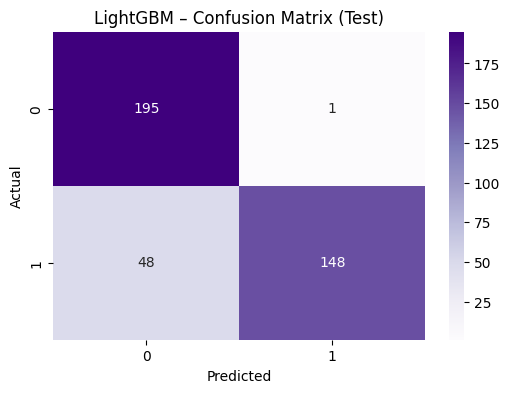

Saved LightGBM booster to: /content/drive/MyDrive/Osteoporosis_project/lifestyle/lightgbm_model.txt
Saved LightGBM booster (joblib) to: /content/drive/MyDrive/Osteoporosis_project/lifestyle/lightgbm_model.pkl


In [ ]:

import os
import pandas as pd
import lightgbm as lgb
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

base = "/content/drive/MyDrive/Osteoporosis_project/lifestyle/"
X_train_path = os.path.join(base, "X_train_preprocessed.csv")
X_test_path  = os.path.join(base, "X_test_preprocessed.csv")
y_train_path = os.path.join(base, "y_train.csv")
y_test_path  = os.path.join(base, "y_test.csv")
save_model_txt = os.path.join(base, "lightgbm_model.txt")
save_model_pkl = os.path.join(base, "lightgbm_model.pkl")


X_train = pd.read_csv(X_train_path)
X_test  = pd.read_csv(X_test_path)
y_train = pd.read_csv(y_train_path).values.ravel()
y_test  = pd.read_csv(y_test_path).values.ravel()

print("Loaded shapes:", X_train.shape, X_test.shape, y_train.shape, y_test.shape)


train_data = lgb.Dataset(X_train, label=y_train)
valid_data = lgb.Dataset(X_test,  label=y_test, reference=train_data)

params = {
    'objective': 'binary',
    'learning_rate': 0.05,
    'max_depth': 6,
    'num_leaves': 40,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 1,
    'lambda_l1': 0.1,
    'lambda_l2': 0.1,
    'metric': 'auc',
    'verbose': -1,
    'force_col_wise': True
}


callbacks = [
    lgb.callback.early_stopping(stopping_rounds=50, first_metric_only=False),
    lgb.callback.log_evaluation(period=0)
]


bst = lgb.train(
    params,
    train_data,
    num_boost_round=1000,
    valid_sets=[train_data, valid_data],
    valid_names=['train', 'valid'],
    callbacks=callbacks
)


train_probs = bst.predict(X_train, num_iteration=bst.best_iteration)
test_probs  = bst.predict(X_test,  num_iteration=bst.best_iteration)

train_preds = (train_probs >= 0.5).astype(int)
test_preds  = (test_probs  >= 0.5).astype(int)

metrics_lgb = {
    "Train Accuracy": accuracy_score(y_train, train_preds),
    "Test Accuracy" : accuracy_score(y_test,  test_preds),
    "Train F1"      : f1_score(y_train, train_preds),
    "Test F1"       : f1_score(y_test,  test_preds),
    "Train AUC"     : roc_auc_score(y_train, train_probs),
    "Test AUC"      : roc_auc_score(y_test,  test_probs),
    "Best Iter"     : bst.best_iteration
}

print("LightGBM metrics:\n", metrics_lgb)


cm = confusion_matrix(y_test, test_preds)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples")
plt.title("LightGBM – Confusion Matrix (Test)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


bst.save_model(save_model_txt)
print("Saved LightGBM booster to:", save_model_txt)


joblib.dump(bst, save_model_pkl)
print("Saved LightGBM booster (joblib) to:", save_model_pkl)


# catboost

In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 7.2 MB/s eta 0:00:00


In [ ]:

import pandas as pd
import numpy as np
import os
from catboost import CatBoostClassifier, Pool
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import joblib

base = "/content/drive/MyDrive/Osteoporosis_project/lifestyle/"

X_train_path = os.path.join(base, "X_train_preprocessed.csv")
X_test_path  = os.path.join(base, "X_test_preprocessed.csv")
y_train_path = os.path.join(base, "y_train.csv")
y_test_path  = os.path.join(base, "y_test.csv")

X_train = pd.read_csv(X_train_path)
X_test  = pd.read_csv(X_test_path)
y_train = pd.read_csv(y_train_path).squeeze()
y_test  = pd.read_csv(y_test_path).squeeze()

print("Loaded shapes:", X_train.shape, X_test.shape, y_train.shape, y_test.shape)


cat_features = np.where(X_train.dtypes == "object")[0]
print("Categorical columns index:", cat_features)

model = CatBoostClassifier(
    iterations=2000,
    learning_rate=0.03,
    depth=6,
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=42,
    od_type="Iter",
    od_wait=50,
    verbose=200
)

train_pool = Pool(X_train, y_train, cat_features=cat_features)
test_pool  = Pool(X_test, y_test, cat_features=cat_features)

model.fit(train_pool, eval_set=test_pool)

y_pred = model.predict(test_pool)
y_prob = model.predict_proba(test_pool)[:, 1]

metrics = {
    "Train Accuracy": accuracy_score(y_train, model.predict(train_pool)),
    "Test Accuracy": accuracy_score(y_test, y_pred),
    "Train F1": f1_score(y_train, model.predict(train_pool)),
    "Test F1": f1_score(y_test, y_pred),
    "Train AUC": roc_auc_score(y_train, model.predict_proba(train_pool)[:, 1]),
    "Test AUC": roc_auc_score(y_test, y_prob)
}

print("\nCatBoost Metrics:")
for k, v in metrics.items():
    print(f"{k}: {v}")


save_path = os.path.join(base, "catboost_model.cbm")
model.save_model(save_path)

print("CatBoost model saved at:", save_path)


joblib_path = save_path.replace(".cbm", ".pkl")
joblib.dump(model, joblib_path)

print("Joblib model saved at:", joblib_path)


Loaded shapes: (1566, 26) (392, 26) (1566,) (392,)
Categorical columns index: []
0:	test: 0.8415504	best: 0.8415504 (0)	total: 57.6ms	remaining: 1m 55s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.8944970845
bestIteration = 89

Shrink model to first 90 iterations.

CatBoost Metrics:
Train Accuracy: 0.9074074074074074
Test Accuracy: 0.8698979591836735
Train F1: 0.8981026001405481
Test F1: 0.8538681948424068
Train AUC: 0.9628251363178919
Test AUC: 0.894497084548105
CatBoost model saved at: /content/drive/MyDrive/Osteoporosis_project/lifestyle/catboost_model.cbm
Joblib model saved at: /content/drive/MyDrive/Osteoporosis_project/lifestyle/catboost_model.pkl


In [ ]:

import os
import pandas as pd
import numpy as np
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report
import joblib

base = "/content/drive/MyDrive/Osteoporosis_project/lifestyle/"
raw_path = os.path.join(base, "osteoporosis.csv")
save_path_cbm = os.path.join(base, "catboost_model.cbm")
save_path_pkl = os.path.join(base, "catboost_model.pkl")


df = pd.read_csv(raw_path)
print("Raw shape:", df.shape)

if "Id" in df.columns:
    df = df.drop(columns=["Id"])
print("After dropping Id shape:", df.shape)


target_col = "Osteoporosis"
X = df.drop(columns=[target_col])
y = df[target_col]

cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
print("Detected categorical columns:", cat_cols)
for c in cat_cols
    X[c] = X[c].astype(object).where(X[c].notna(), other="Unknown").astype(str)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print("Train/Test shapes:", X_train.shape, X_test.shape)

cat_feature_indices = [X_train.columns.get_loc(c) for c in cat_cols]
print("Cat feature indices:", cat_feature_indices)

train_pool = Pool(X_train, y_train, cat_features=cat_feature_indices)
valid_pool = Pool(X_test, y_test, cat_features=cat_feature_indices)

model = CatBoostClassifier(
    iterations=2000,
    learning_rate=0.03,
    depth=6,
    l2_leaf_reg=5,
    loss_function='Logloss',
    eval_metric='AUC',
    random_seed=42,
    od_type='Iter',
    od_wait=50,
    verbose=100
)

model.fit(train_pool, eval_set=valid_pool)


train_probs = model.predict_proba(train_pool)[:, 1]
test_probs  = model.predict_proba(valid_pool)[:, 1]
train_preds = (train_probs >= 0.5).astype(int)
test_preds  = (test_probs >= 0.5).astype(int)

metrics = {
    "Train Accuracy": accuracy_score(y_train, train_preds),
    "Test Accuracy": accuracy_score(y_test, test_preds),
    "Train F1": f1_score(y_train, train_preds),
    "Test F1": f1_score(y_test, test_preds),
    "Train AUC": roc_auc_score(y_train, train_probs),
    "Test AUC": roc_auc_score(y_test, test_probs),
    "Best Iter": model.get_best_iteration()
}

print("\nCatBoost metrics:")
for k,v in metrics.items():
    print(f"{k}: {v}")

print("\nClassification report (test):")
print(classification_report(y_test, test_preds))


model.save_model(save_path_cbm)
joblib.dump(model, save_path_pkl)
print("Saved CatBoost model to:", save_path_cbm, "and", save_path_pkl)


Raw shape: (1958, 16)
After dropping Id shape: (1958, 15)
Detected categorical columns: ['Gender', 'Hormonal Changes', 'Family History', 'Race/Ethnicity', 'Body Weight', 'Calcium Intake', 'Vitamin D Intake', 'Physical Activity', 'Smoking', 'Alcohol Consumption', 'Medical Conditions', 'Medications', 'Prior Fractures']
Train/Test shapes: (1566, 14) (392, 14)
Cat feature indices: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]
0:	test: 0.8620887	best: 0.8620887 (0)	total: 15.8ms	remaining: 31.5s
100:	test: 0.8949656	best: 0.8956945 (54)	total: 1.11s	remaining: 20.9s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.8956945023
bestIteration = 54

Shrink model to first 55 iterations.

CatBoost metrics:
Train Accuracy: 0.8946360153256705
Test Accuracy: 0.8647959183673469
Train F1: 0.8865979381443299
Test F1: 0.8507042253521127
Train AUC: 0.9315368568021936
Test AUC: 0.8956945022907121
Best Iter: 54

Classification report (test):
              precision    recall  f1-score   sup

In [ ]:
import pandas as pd
import joblib
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import os

base = "/content/drive/MyDrive/Osteoporosis_project/lifestyle/"
X_test_path  = os.path.join(base, "X_test_preprocessed.csv")
y_test_path  = os.path.join(base, "y_test.csv")

X_test = pd.read_csv(X_test_path)
y_test = pd.read_csv(y_test_path).values.ravel()

models = {
    "Logistic Regression": joblib.load(os.path.join(base, "logistic_regression_model.pkl")),
    "Random Forest"      : joblib.load(os.path.join(base, "random_forest_model.pkl")),
    "XGBoost"            : joblib.load(os.path.join(base, "xgboost_model_tuned.pkl")),
    "LightGBM"           : joblib.load(os.path.join(base, "lightgbm_model.pkl")),
    "CatBoost"           : joblib.load(os.path.join(base, "catboost_model.pkl"))
}

print("Loaded all models and test data.")


Loaded all models and test data.


# COMPARISON

In [ ]:
import os
import pandas as pd
import joblib
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report


base = "/content/drive/MyDrive/Osteoporosis_project/lifestyle/"
X_train_path = os.path.join(base, "X_train_preprocessed.csv")
X_test_path  = os.path.join(base, "X_test_preprocessed.csv")
y_train_path = os.path.join(base, "y_train.csv")
y_test_path  = os.path.join(base, "y_test.csv")
model_path   = os.path.join(base, "logistic_regression_model.pkl")


X_train = pd.read_csv(X_train_path)
X_test  = pd.read_csv(X_test_path)
y_train = pd.read_csv(y_train_path).values.ravel()
y_test  = pd.read_csv(y_test_path).values.ravel()

print("Shapes:", X_train.shape, X_test.shape)


logreg = joblib.load(model_path)
print("Loaded Logistic Regression model from:", model_path)


train_preds = logreg.predict(X_train)
test_preds  = logreg.predict(X_test)

train_probs = logreg.predict_proba(X_train)[:, 1]
test_probs  = logreg.predict_proba(X_test)[:, 1]


metrics_LR = {
    "Train Accuracy": accuracy_score(y_train, train_preds),
    "Test Accuracy": accuracy_score(y_test, test_preds),
    "Train F1": f1_score(y_train, train_preds),
    "Test F1": f1_score(y_test, test_preds),
    "Train AUC": roc_auc_score(y_train, train_probs),
    "Test AUC": roc_auc_score(y_test, test_probs)
}

print("\nLogistic Regression Metrics:")
for k, v in metrics_LR.items():
    print(f"{k}: {v:.4f}")

print("\nClassification Report (Test):")
print(classification_report(y_test, test_preds))


Shapes: (1566, 26) (392, 26)
Loaded Logistic Regression model from: /content/drive/MyDrive/Osteoporosis_project/lifestyle/logistic_regression_model.pkl

Logistic Regression Metrics:
Train Accuracy: 0.8308
Test Accuracy: 0.7934
Train F1: 0.8237
Test F1: 0.7805
Train AUC: 0.9117
Test AUC: 0.8758

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.76      0.85      0.80       196
           1       0.83      0.73      0.78       196

    accuracy                           0.79       392
   macro avg       0.80      0.79      0.79       392
weighted avg       0.80      0.79      0.79       392



In [ ]:
import os
import pandas as pd
import joblib
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report

base = "/content/drive/MyDrive/Osteoporosis_project/lifestyle/"
X_train_path = os.path.join(base, "X_train_preprocessed.csv")
X_test_path  = os.path.join(base, "X_test_preprocessed.csv")
y_train_path = os.path.join(base, "y_train.csv")
y_test_path  = os.path.join(base, "y_test.csv")
rf_model_path = os.path.join(base, "random_forest_model.pkl")

X_train = pd.read_csv(X_train_path)
X_test  = pd.read_csv(X_test_path)
y_train = pd.read_csv(y_train_path).values.ravel()
y_test  = pd.read_csv(y_test_path).values.ravel()

print("Shapes:", X_train.shape, X_test.shape)


rf_model = joblib.load(rf_model_path)
print("Loaded Random Forest model from:", rf_model_path)


train_preds = rf_model.predict(X_train)
test_preds  = rf_model.predict(X_test)

train_probs = rf_model.predict_proba(X_train)[:, 1]
test_probs  = rf_model.predict_proba(X_test)[:, 1]


metrics_RF = {
    "Train Accuracy": accuracy_score(y_train, train_preds),
    "Test Accuracy": accuracy_score(y_test, test_preds),
    "Train F1": f1_score(y_train, train_preds),
    "Test F1": f1_score(y_test, test_preds),
    "Train AUC": roc_auc_score(y_train, train_probs),
    "Test AUC": roc_auc_score(y_test, test_probs)
}

print("\nRandom Forest Metrics:")
for k, v in metrics_RF.items():
    print(f"{k}: {v:.4f}")

print("\nClassification Report (Test):")
print(classification_report(y_test, test_preds))


Shapes: (1566, 26) (392, 26)
Loaded Random Forest model from: /content/drive/MyDrive/Osteoporosis_project/lifestyle/random_forest_model.pkl

Random Forest Metrics:
Train Accuracy: 0.8825
Test Accuracy: 0.8393
Train F1: 0.8671
Test F1: 0.8142
Train AUC: 0.9769
Test AUC: 0.8812

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.77      0.97      0.86       196
           1       0.97      0.70      0.81       196

    accuracy                           0.84       392
   macro avg       0.87      0.84      0.84       392
weighted avg       0.87      0.84      0.84       392



In [ ]:
import os
import pandas as pd
import joblib
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report


base = "/content/drive/MyDrive/Osteoporosis_project/lifestyle/"
X_train_path = os.path.join(base, "X_train_preprocessed.csv")
X_test_path  = os.path.join(base, "X_test_preprocessed.csv")
y_train_path = os.path.join(base, "y_train.csv")
y_test_path  = os.path.join(base, "y_test.csv")
xgb_model_path = os.path.join(base, "xgboost_model_tuned.pkl")


X_train = pd.read_csv(X_train_path)
X_test  = pd.read_csv(X_test_path)
y_train = pd.read_csv(y_train_path).values.ravel()
y_test  = pd.read_csv(y_test_path).values.ravel()

print("Shapes:", X_train.shape, X_test.shape)

xgb_model = joblib.load(xgb_model_path)
print("Loaded XGBoost model from:", xgb_model_path)


train_preds = xgb_model.predict(X_train)
test_preds  = xgb_model.predict(X_test)

train_probs = xgb_model.predict_proba(X_train)[:, 1]
test_probs  = xgb_model.predict_proba(X_test)[:, 1]

metrics_XG = {
    "Train Accuracy": accuracy_score(y_train, train_preds),
    "Test Accuracy": accuracy_score(y_test, test_preds),
    "Train F1": f1_score(y_train, train_preds),
    "Test F1": f1_score(y_test, test_preds),
    "Train AUC": roc_auc_score(y_train, train_probs),
    "Test AUC": roc_auc_score(y_test, test_probs)
}

print("\nXGBoost Metrics:")
for k, v in metrics_XG.items():
    print(f"{k}: {v:.4f}")

print("\nClassification Report (Test):")
print(classification_report(y_test, test_preds))


Shapes: (1566, 26) (392, 26)
Loaded XGBoost model from: /content/drive/MyDrive/Osteoporosis_project/lifestyle/xgboost_model_tuned.pkl

XGBoost Metrics:
Train Accuracy: 0.9240
Test Accuracy: 0.8852
Train F1: 0.9179
Test F1: 0.8711
Train AUC: 0.9732
Test AUC: 0.8846

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.82      0.99      0.90       196
           1       0.99      0.78      0.87       196

    accuracy                           0.89       392
   macro avg       0.90      0.89      0.88       392
weighted avg       0.90      0.89      0.88       392



In [ ]:
import os
import pandas as pd
import lightgbm as lgb
import joblib
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix


base = "/content/drive/MyDrive/Osteoporosis_project/lifestyle/"
X_train_path = os.path.join(base, "X_train_preprocessed.csv")
X_test_path  = os.path.join(base, "X_test_preprocessed.csv")
y_train_path = os.path.join(base, "y_train.csv")
y_test_path  = os.path.join(base, "y_test.csv")
lgb_model_path = os.path.join(base, "lightgbm_model.pkl")  # joblib version

X_train = pd.read_csv(X_train_path)
X_test  = pd.read_csv(X_test_path)
y_train = pd.read_csv(y_train_path).values.ravel()
y_test  = pd.read_csv(y_test_path).values.ravel()

print("Loaded shapes:", X_train.shape, X_test.shape, y_train.shape, y_test.shape)


bst = joblib.load(lgb_model_path)
print("Loaded LightGBM model from:", lgb_model_path)


train_probs = bst.predict(X_train, num_iteration=bst.best_iteration)
test_probs  = bst.predict(X_test,  num_iteration=bst.best_iteration)

train_preds = (train_probs >= 0.5).astype(int)
test_preds  = (test_probs  >= 0.5).astype(int)

metrics_lgb = {
    "Train Accuracy": accuracy_score(y_train, train_preds),
    "Test Accuracy" : accuracy_score(y_test,  test_preds),
    "Train F1"      : f1_score(y_train, train_preds),
    "Test F1"       : f1_score(y_test,  test_preds),
    "Train AUC"     : roc_auc_score(y_train, train_probs),
    "Test AUC"      : roc_auc_score(y_test,  test_probs),
    "Best Iter"     : bst.best_iteration
}

print("\nLightGBM Metrics:")
for k,v in metrics_lgb.items():
    print(f"{k}: {v:.4f}")


print("\nClassification Report (Test):")
print(classification_report(y_test, test_preds))


cm = confusion_matrix(y_test, test_preds)
print("\nConfusion Matrix (Test):")
print(cm)


Loaded shapes: (1566, 26) (392, 26) (1566,) (392,)
Loaded LightGBM model from: /content/drive/MyDrive/Osteoporosis_project/lifestyle/lightgbm_model.pkl

LightGBM Metrics:
Train Accuracy: 0.9074
Test Accuracy: 0.8750
Train F1: 0.8980
Test F1: 0.8580
Train AUC: 0.9609
Test AUC: 0.8994
Best Iter: 35.0000

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.80      0.99      0.89       196
           1       0.99      0.76      0.86       196

    accuracy                           0.88       392
   macro avg       0.90      0.88      0.87       392
weighted avg       0.90      0.88      0.87       392


Confusion Matrix (Test):
[[195   1]
 [ 48 148]]


In [ ]:
import os
import pandas as pd
import numpy as np
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report


base = "/content/drive/MyDrive/Osteoporosis_project/lifestyle/"
raw_path = os.path.join(base, "osteoporosis.csv")
save_path_cbm = os.path.join(base, "catboost_model.cbm")

df = pd.read_csv(raw_path)
if "Id" in df.columns:
    df = df.drop(columns=["Id"])

target_col = "Osteoporosis"
X = df.drop(columns=[target_col])
y = df[target_col]


cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
for c in cat_cols:
    X[c] = X[c].astype(object).where(X[c].notna(), other="Unknown").astype(str)


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

cat_feature_indices = [X_train.columns.get_loc(c) for c in cat_cols]

train_pool = Pool(X_train, y_train, cat_features=cat_feature_indices)
test_pool  = Pool(X_test, y_test,  cat_features=cat_feature_indices)

model = CatBoostClassifier()
model.load_model(save_path_cbm)

print("CatBoost model loaded successfully!")

# ------------------------
# Evaluate
# ------------------------
train_probs = model.predict_proba(train_pool)[:, 1]
test_probs  = model.predict_proba(test_pool)[:, 1]

train_preds = (train_probs >= 0.5).astype(int)
test_preds  = (test_probs >= 0.5).astype(int)

metrics_cat = {
    "Train Accuracy": accuracy_score(y_train, train_preds),
    "Test Accuracy": accuracy_score(y_test, test_preds),
    "Train F1": f1_score(y_train, train_preds),
    "Test F1": f1_score(y_test, test_preds),
    "Train AUC": roc_auc_score(y_train, train_probs),
    "Test AUC": roc_auc_score(y_test, test_probs),
    "Best Iter": model.get_best_iteration()
}

print("\nCATBOOST (Reloaded) METRICS:")
for k, v in metrics_cat.items():
    print(f"{k}: {v}")

print("\nClassification Report (Test):")
print(classification_report(y_test, test_preds))


CatBoost model loaded successfully!

CATBOOST (Reloaded) METRICS:
Train Accuracy: 0.8946360153256705
Test Accuracy: 0.8647959183673469
Train F1: 0.8865979381443299
Test F1: 0.8507042253521127
Train AUC: 0.9315368568021936
Test AUC: 0.8956945022907121
Best Iter: 54

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.81      0.96      0.88       196
           1       0.95      0.77      0.85       196

    accuracy                           0.86       392
   macro avg       0.88      0.86      0.86       392
weighted avg       0.88      0.86      0.86       392



In [ ]:
import pandas as pd

all_metrics = pd.DataFrame([
    metrics_LR,
    metrics_RF,
    metrics_XG,
    metrics_lgb,
    metrics_cat
], index=["Logistic Regression", "Random Forest", "XGBoost", "LightGBM", "CatBoost"])


all_metrics = all_metrics.round(4)

print("All Model Metrics:\n")
display(all_metrics)


All Model Metrics:



,Train Accuracy,Test Accuracy,Train F1,Test F1,Train AUC,Test AUC,Best Iter
Logistic Regression,0.8308,0.7934,0.8237,0.7805,0.9117,0.8758,NaN
Random Forest,0.8825,0.8393,0.8671,0.8142,0.9769,0.8812,NaN
XGBoost,0.9240,0.8852,0.9179,0.8711,0.9732,0.8846,NaN
LightGBM,0.9074,0.8750,0.8980,0.8580,0.9609,0.8994,35.0
CatBoost,0.8946,0.8648,0.8866,0.8507,0.9315,0.8957,54.0


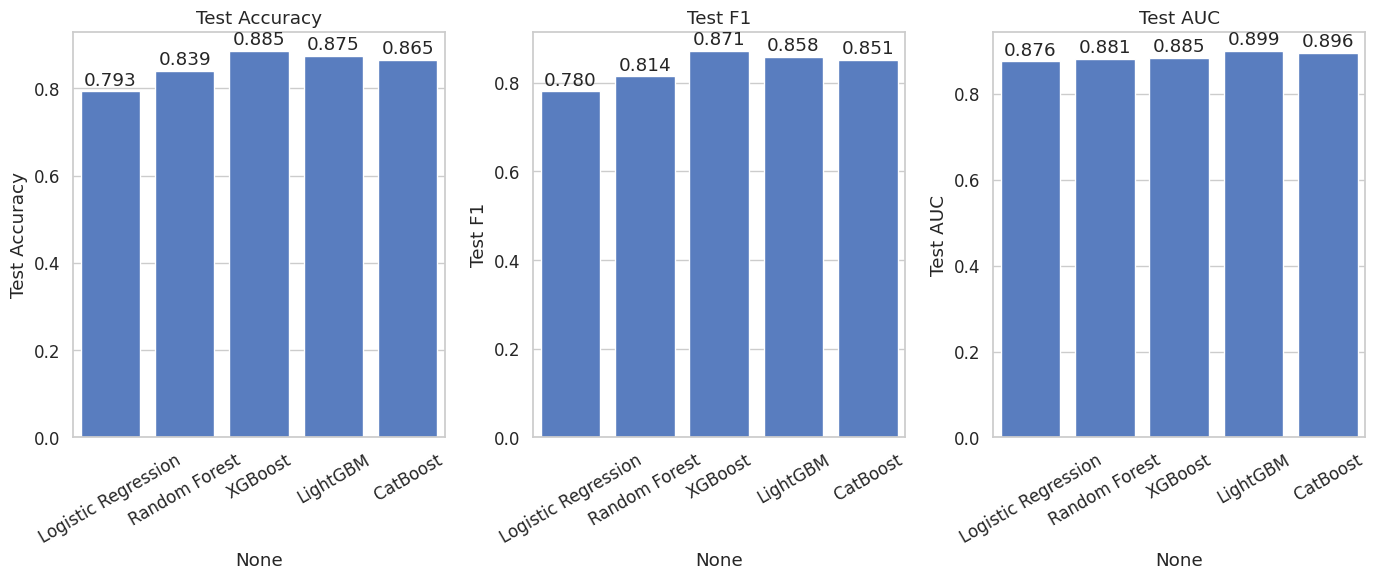

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


sns.set(style="whitegrid", palette="muted", font_scale=1.1)


metrics_to_plot = ["Test Accuracy", "Test F1", "Test AUC"]

plt.figure(figsize=(14, 6))

for i, metric in enumerate(metrics_to_plot, 1):
    plt.subplot(1, len(metrics_to_plot), i)
    sns.barplot(x=all_metrics.index, y=all_metrics[metric])
    plt.title(metric)
    plt.ylabel(metric)
    plt.xticks(rotation=30)
    for j, val in enumerate(all_metrics[metric]):
        plt.text(j, val + 0.005, f"{val:.3f}", ha='center', va='bottom')
plt.tight_layout()
plt.show()


# soft voting

In [ ]:
from catboost import CatBoostClassifier
import joblib

base = "/content/drive/MyDrive/Osteoporosis_project/lifestyle/"

X_train_pre = pd.read_csv(base + "X_train_preprocessed.csv")
y_train = pd.read_csv(base + "y_train.csv").values.ravel()

model_cat_pre = CatBoostClassifier(
    iterations=2000,
    learning_rate=0.03,
    depth=6,
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=42,
    verbose=100
)

model_cat_pre.fit(X_train_pre, y_train)


model_cat_pre.save_model(base + "catboost_preprocessed.cbm")
joblib.dump(model_cat_pre, base + "catboost_preprocessed.pkl")

print("CatBoost retrained on preprocessed data.")


0:	total: 57.5ms	remaining: 1m 54s
100:	total: 589ms	remaining: 11.1s
200:	total: 1.19s	remaining: 10.6s
300:	total: 1.93s	remaining: 10.9s
400:	total: 2.59s	remaining: 10.3s
500:	total: 3.37s	remaining: 10.1s
600:	total: 3.99s	remaining: 9.29s
700:	total: 4.6s	remaining: 8.53s
800:	total: 5.06s	remaining: 7.57s
900:	total: 5.42s	remaining: 6.61s
1000:	total: 5.77s	remaining: 5.76s
1100:	total: 6.08s	remaining: 4.97s
1200:	total: 6.34s	remaining: 4.22s
1300:	total: 6.58s	remaining: 3.53s
1400:	total: 6.98s	remaining: 2.98s
1500:	total: 7.36s	remaining: 2.45s
1600:	total: 7.71s	remaining: 1.92s
1700:	total: 8.07s	remaining: 1.42s
1800:	total: 8.42s	remaining: 930ms
1900:	total: 8.85s	remaining: 461ms
1999:	total: 9.15s	remaining: 0us
CatBoost retrained on preprocessed data.


Shapes: (1566, 26) (392, 26) (1566,) (392,)
CatBoost model loaded successfully!

📌 Soft Voting Ensemble Metrics:
Accuracy: 0.8827
F1 Score: 0.8678
AUC: 0.8931

Classification Report (Ensemble):
              precision    recall  f1-score   support

           0       0.81      0.99      0.89       196
           1       0.99      0.77      0.87       196

    accuracy                           0.88       392
   macro avg       0.90      0.88      0.88       392
weighted avg       0.90      0.88      0.88       392



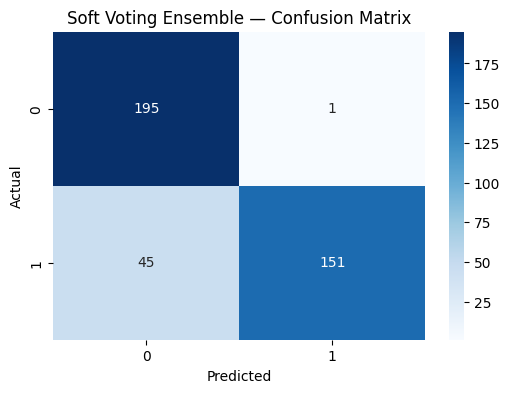

In [ ]:

import os
import pandas as pd
import numpy as np
import joblib
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


base = "/content/drive/MyDrive/Osteoporosis_project/lifestyle/"

X_train_path = os.path.join(base, "X_train_preprocessed.csv")
X_test_path  = os.path.join(base, "X_test_preprocessed.csv")
y_train_path = os.path.join(base, "y_train.csv")
y_test_path  = os.path.join(base, "y_test.csv")


xgb_model_path = os.path.join(base, "xgboost_model_tuned.pkl")
lgb_model_path = os.path.join(base, "lightgbm_model.pkl")
cat_model_path = os.path.join(base, "catboost_model.cbm")
raw_data_path = os.path.join(base, "osteoporosis.csv")


X_train = pd.read_csv(X_train_path)
X_test  = pd.read_csv(X_test_path)
y_train = pd.read_csv(y_train_path).values.ravel()
y_test  = pd.read_csv(y_test_path).values.ravel()

print("Shapes:", X_train.shape, X_test.shape, y_train.shape, y_test.shape)

xgb_model = joblib.load(xgb_model_path)
bst       = joblib.load(lgb_model_path)

df = pd.read_csv(raw_data_path)
if "Id" in df.columns:
    df = df.drop(columns=["Id"])

target_col = "Osteoporosis"
X = df.drop(columns=[target_col])
y = df[target_col]

cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
for c in cat_cols:
    X[c] = X[c].astype(object).where(X[c].notna(), other="Unknown").astype(str)


X_train_cb, X_test_cb, y_train_cb, y_test_cb = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# CatBoost feature indices
cat_feature_indices = [X_train_cb.columns.get_loc(c) for c in cat_cols]

train_pool = Pool(X_train_cb, y_train_cb, cat_features=cat_feature_indices)
test_pool  = Pool(X_test_cb, y_test_cb, cat_features=cat_feature_indices)

model = CatBoostClassifier()
model.load_model(cat_model_path)
print("CatBoost model loaded successfully!")

probs_xgb = xgb_model.predict_proba(X_test)[:, 1]
probs_lgb = bst.predict(X_test, num_iteration=bst.best_iteration)
probs_cat = model.predict_proba(test_pool)[:, 1]  # now shape matches

probs_ensemble = (probs_xgb + probs_lgb + probs_cat) / 3
preds_ensemble = (probs_ensemble >= 0.5).astype(int)


ens_metrics = {
    "Accuracy": accuracy_score(y_test, preds_ensemble),
    "F1 Score": f1_score(y_test, preds_ensemble),
    "AUC": roc_auc_score(y_test, probs_ensemble)
}

print("\n Soft Voting Ensemble Metrics:")
for k, v in ens_metrics.items():
    print(f"{k}: {v:.4f}")

print("\nClassification Report (Ensemble):")
print(classification_report(y_test, preds_ensemble))


cm = confusion_matrix(y_test, preds_ensemble)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Soft Voting Ensemble — Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


Test shapes: (392, 26) (392,)
XGBoost loaded
LightGBM loaded
CatBoost loaded
Optimal threshold for ensemble: 0.56

📌 Soft Voting Ensemble Metrics:
Accuracy: 0.8878
F1 Score: 0.8736
AUC: 0.8800

Classification Report (Ensemble):
              precision    recall  f1-score   support

           0       0.82      1.00      0.90       196
           1       1.00      0.78      0.87       196

    accuracy                           0.89       392
   macro avg       0.91      0.89      0.89       392
weighted avg       0.91      0.89      0.89       392



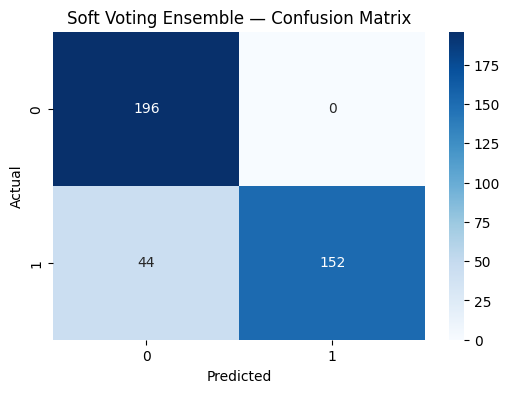

In [ ]:
import numpy as np
import pandas as pd
import joblib
from catboost import CatBoostClassifier, Pool
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


base = "/content/drive/MyDrive/Osteoporosis_project/lifestyle/"
X_test_path = base + "X_test_preprocessed.csv"
y_test_path = base + "y_test.csv"
xgb_model_path = base + "xgboost_model_tuned.pkl"
lgb_model_path = base + "lightgbm_model.pkl"
cat_model_path = base + "catboost_model.cbm"


X_test = pd.read_csv(X_test_path)
y_test = pd.read_csv(y_test_path).values.ravel()
print("Test shapes:", X_test.shape, y_test.shape)

xgb_model = joblib.load(xgb_model_path)
print("XGBoost loaded")

bst = joblib.load(lgb_model_path)
print("LightGBM loaded")


df_raw = pd.read_csv(base + "osteoporosis.csv")
if "Id" in df_raw.columns:
    df_raw = df_raw.drop(columns=["Id"])
target_col = "Osteoporosis"
X_cat = df_raw.drop(columns=[target_col])
y_cat = df_raw[target_col]
cat_cols = X_cat.select_dtypes(include=["object", "category"]).columns.tolist()
for c in cat_cols:
    X_cat[c] = X_cat[c].astype(object).where(X_cat[c].notna(), other="Unknown").astype(str)
X_train_cat, X_test_cat, y_train_cat, y_test_cat = X_cat.loc[X_cat.index.difference(X_test.index)], X_cat.loc[X_test.index], y_cat.loc[y_cat.index.difference(X_test.index)], y_cat.loc[X_test.index]
cat_feature_indices = [X_train_cat.columns.get_loc(c) for c in cat_cols]
test_pool = Pool(X_test_cat, y_test_cat, cat_features=cat_feature_indices)
model_cat = CatBoostClassifier()
model_cat.load_model(cat_model_path)
print("CatBoost loaded")


probs_xgb = xgb_model.predict_proba(X_test)[:, 1]
probs_lgb = bst.predict(X_test, num_iteration=bst.best_iteration)
probs_cat = model_cat.predict_proba(test_pool)[:, 1]


weights = [2, 2, 1]  # [XGB, LGB, CAT]

probs_ensemble = (weights[0]*probs_xgb + weights[1]*probs_lgb + weights[2]*probs_cat) / sum(weights)


thresholds = np.arange(0.4, 0.61, 0.01)
best_f1 = 0
best_thresh = 0.5
for t in thresholds:
    preds = (probs_ensemble >= t).astype(int)
    f1 = f1_score(y_test, preds)
    if f1 > best_f1:
        best_f1 = f1
        best_thresh = t

preds_ensemble = (probs_ensemble >= best_thresh).astype(int)
print(f"Optimal threshold for ensemble: {best_thresh:.2f}")

ens_metrics = {
    "Accuracy": accuracy_score(y_test, preds_ensemble),
    "F1 Score": f1_score(y_test, preds_ensemble),
    "AUC": roc_auc_score(y_test, probs_ensemble)
}

print("\n Soft Voting Ensemble Metrics:")
for k, v in ens_metrics.items():
    print(f"{k}: {v:.4f}")

print("\nClassification Report (Ensemble):")
print(classification_report(y_test, preds_ensemble))

cm = confusion_matrix(y_test, preds_ensemble)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Soft Voting Ensemble — Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# best one

Test shapes: (392, 26) (392,)
XGBoost loaded
LightGBM loaded
CatBoost loaded

 BEST WEIGHTED SOFT VOTING RESULT
wx: 2
wl: 4
wc: 1
threshold: 0.5300
Accuracy: 0.8878
F1: 0.8736
AUC: 0.8857

Classification Report (Best Ensemble):
              precision    recall  f1-score   support

           0       0.82      1.00      0.90       196
           1       1.00      0.78      0.87       196

    accuracy                           0.89       392
   macro avg       0.91      0.89      0.89       392
weighted avg       0.91      0.89      0.89       392



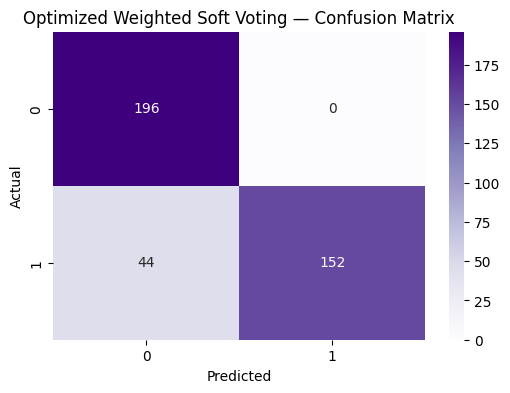

In [ ]:
import numpy as np
import pandas as pd
import joblib
from catboost import CatBoostClassifier, Pool
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


base = "/content/drive/MyDrive/Osteoporosis_project/lifestyle/"
X_test_path = base + "X_test_preprocessed.csv"
y_test_path = base + "y_test.csv"
xgb_model_path = base + "xgboost_model_tuned.pkl"
lgb_model_path = base + "lightgbm_model.pkl"
cat_model_path = base + "catboost_model.cbm"


X_test = pd.read_csv(X_test_path)
y_test = pd.read_csv(y_test_path).values.ravel()
print("Test shapes:", X_test.shape, y_test.shape)

xgb_model = joblib.load(xgb_model_path)
print("XGBoost loaded")

bst = joblib.load(lgb_model_path)
print("LightGBM loaded")


df_raw = pd.read_csv(base + "osteoporosis.csv")
if "Id" in df_raw.columns:
    df_raw = df_raw.drop(columns=["Id"])

target_col = "Osteoporosis"
X_cat = df_raw.drop(columns=[target_col])
y_cat = df_raw[target_col]


cat_cols = X_cat.select_dtypes(include=["object", "category"]).columns.tolist()
for c in cat_cols:
    X_cat[c] = X_cat[c].astype(object).where(X_cat[c].notna(), other="Unknown").astype(str)

X_test_cat = X_cat.loc[X_test.index]
y_test_cat = y_cat.loc[X_test.index]

cat_feature_indices = [X_cat.columns.get_loc(c) for c in cat_cols]
test_pool = Pool(X_test_cat, y_test_cat, cat_features=cat_feature_indices)

model_cat = CatBoostClassifier()
model_cat.load_model(cat_model_path)
print("CatBoost loaded")


probs_xgb = xgb_model.predict_proba(X_test)[:, 1]
probs_lgb = bst.predict(X_test, num_iteration=bst.best_iteration)
probs_cat = model_cat.predict_proba(test_pool)[:, 1]


xgb_w = [1, 2, 3, 4, 5]
lgb_w = [1, 2, 3, 4]
cat_w = [1, 2, 3, 4]

thresholds = np.arange(0.40, 0.61, 0.01)

best_combo = None
best_score = -1

for wx in xgb_w:
    for wl in lgb_w:
        for wc in cat_w:
            ensemble_prob = (wx*probs_xgb + wl*probs_lgb + wc*probs_cat) / (wx + wl + wc)

            for t in thresholds:
                preds = (ensemble_prob >= t).astype(int)

                acc = accuracy_score(y_test, preds)
                f1 = f1_score(y_test, preds)
                auc = roc_auc_score(y_test, ensemble_prob)

                penalty = 0
                if acc < 0.90: penalty += (0.90 - acc)
                if f1 < 0.90: penalty += (0.90 - f1)
                if auc < 0.90: penalty += (0.90 - auc)

                score = (acc + f1 + auc) - penalty*3

                if score > best_score:
                    best_score = score
                    best_combo = {
                        "wx": wx,
                        "wl": wl,
                        "wc": wc,
                        "threshold": t,
                        "Accuracy": acc,
                        "F1": f1,
                        "AUC": auc
                    }


print("\n==============================")
print(" BEST WEIGHTED SOFT VOTING RESULT")
print("==============================")

for k, v in best_combo.items():
    if isinstance(v, float):
        print(f"{k}: {v:.4f}")
    else:
        print(f"{k}: {v}")


wx, wl, wc = best_combo["wx"], best_combo["wl"], best_combo["wc"]
t = best_combo["threshold"]

final_probs = (wx*probs_xgb + wl*probs_lgb + wc*probs_cat) / (wx + wl + wc)
final_preds = (final_probs >= t).astype(int)

print("\nClassification Report (Best Ensemble):")
print(classification_report(y_test, final_preds))


cm = confusion_matrix(y_test, final_preds)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples")
plt.title("Optimized Weighted Soft Voting — Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [ ]:
import numpy as np
import pandas as pd


np.save("/content/drive/MyDrive/Osteoporosis_project/lifestyle/best_ensemble/ensemble_probs.npy", final_probs)

np.save("/content/drive/MyDrive/Osteoporosis_project/lifestyle/best_ensemble/ensemble_preds.npy", final_preds)

df_ensemble = pd.DataFrame({
    "Prediction": final_preds,
    "Probability": final_probs
})
df_ensemble.to_csv("/content/drive/MyDrive/Osteoporosis_project/lifestyle/best_ensemble/ensemble_predictions.csv", index=False)


In [ ]:
import joblib
import json
import os


base = "/content/drive/MyDrive/Osteoporosis_project/lifestyle/"
save_dir = os.path.join(base, "best_ensemble")
os.makedirs(save_dir, exist_ok=True)


ensemble_config = {
    "wx": best_combo["wx"],
    "wl": best_combo["wl"],
    "wc": best_combo["wc"],
    "threshold": best_combo["threshold"]
}

with open(os.path.join(save_dir, "ensemble_config.json"), "w") as f:
    json.dump(ensemble_config, f, indent=4)


pd.DataFrame(final_preds, columns=["Prediction"]).to_csv(
    os.path.join(save_dir, "final_predictions.csv"), index=False
)

pd.DataFrame(final_probs, columns=["Probability"]).to_csv(
    os.path.join(save_dir, "final_probabilities.csv"), index=False
)


joblib.dump(xgb_model, os.path.join(save_dir, "xgb_model.pkl"))
joblib.dump(bst, os.path.join(save_dir, "lgb_model.pkl"))
model_cat.save_model(os.path.join(save_dir, "catboost_model.cbm"))

print(f"Best weighted soft voting ensemble saved at: {save_dir}")


Best weighted soft voting ensemble saved at: /content/drive/MyDrive/Osteoporosis_project/lifestyle/best_ensemble


# stacking ensemble

Shapes: (1566, 26) (392, 26) (1566,) (392,)
Loaded XGBoost from: /content/drive/MyDrive/Osteoporosis_project/lifestyle/xgboost_model_tuned.pkl
Loaded LightGBM from: /content/drive/MyDrive/Osteoporosis_project/lifestyle/lightgbm_model.pkl
Retraining CatBoost on preprocessed numeric training data (this keeps feature alignment consistent).
0:	test: 0.8415504	best: 0.8415504 (0)	total: 10.1ms	remaining: 10.1s
100:	test: 0.8940546	best: 0.8944971 (89)	total: 510ms	remaining: 4.54s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.8944970845
bestIteration = 89

Shrink model to first 90 iterations.
Saved retrained CatBoost to: /content/drive/MyDrive/Osteoporosis_project/lifestyle/catboost_model.pkl

Fold 1/5
LightGBM refit failed, using loaded object for predictions; error: LGBMClassifier.fit() got an unexpected keyword argument 'early_stopping_rounds'

Fold 2/5
LightGBM refit failed, using loaded object for predictions; error: LGBMClassifier.fit() got an unexpected keyword 

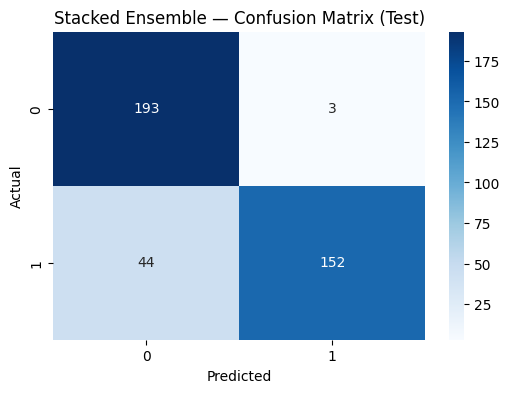

Best meta threshold by F1: 0.6800000000000004 F1: 0.8710601719197708
Metrics after tuning threshold:
Accuracy: 0.8852040816326531
F1: 0.8710601719197708
AUC: 0.8874947938359018


In [ ]:
# Stacking ensemble: XGBoost + LightGBM + CatBoost -> LogisticRegression meta
import os
import numpy as np
import pandas as pd
import joblib
from sklearn.model_selection import KFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


base = "/content/drive/MyDrive/Osteoporosis_project/lifestyle/"
X_train_path = os.path.join(base, "X_train_preprocessed.csv")
X_test_path  = os.path.join(base, "X_test_preprocessed.csv")
y_train_path = os.path.join(base, "y_train.csv")
y_test_path  = os.path.join(base, "y_test.csv")

xgb_model_path = os.path.join(base, "xgboost_model_tuned.pkl")
lgb_model_path = os.path.join(base, "lightgbm_model.pkl")
cat_model_path = os.path.join(base, "catboost_model.pkl")

stacked_model_path = os.path.join(base, "stacked_meta_model.pkl")
oof_dir = os.path.join(base, "stacking_oof")
os.makedirs(oof_dir, exist_ok=True)


X_train = pd.read_csv(X_train_path)
X_test  = pd.read_csv(X_test_path)
y_train = pd.read_csv(y_train_path).squeeze().values
y_test  = pd.read_csv(y_test_path).squeeze().values

print("Shapes:", X_train.shape, X_test.shape, y_train.shape, y_test.shape)


xgb_model = joblib.load(xgb_model_path)
print("Loaded XGBoost from:", xgb_model_path)

lgb_loaded = joblib.load(lgb_model_path)
print("Loaded LightGBM from:", lgb_model_path)

def get_xgb_proba(model, X):
    # sklearn XGBClassifier
    return model.predict_proba(X)[:, 1]

def get_lgb_proba(lgb_obj, X):
    # If lgb_obj is sklearn LGBMClassifier -> it has predict_proba
    try:
        return lgb_obj.predict_proba(X)[:, 1]
    except Exception:

        return lgb_obj.predict(X, num_iteration=getattr(lgb_obj, "best_iteration", None) or None)

from catboost import CatBoostClassifier

cat_retrain = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.03,
    depth=6,
    loss_function='Logloss',
    eval_metric='AUC',
    random_seed=42,
    od_type='Iter',
    od_wait=50,
    verbose=100
)

print("Retraining CatBoost on preprocessed numeric training data (this keeps feature alignment consistent).")
cat_retrain.fit(X_train, y_train, eval_set=(X_test, y_test))

joblib.dump(cat_retrain, cat_model_path)
print("Saved retrained CatBoost to:", cat_model_path)

def get_cat_proba(cat_model, X):
    return cat_model.predict_proba(X)[:, 1]


n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

oof_train = np.zeros((X_train.shape[0], 3))   # columns: xgb, lgb, cat
oof_test = np.zeros((X_test.shape[0], 3, n_splits))  # for averaging across folds

fold_idx = 0
for train_idx, val_idx in kf.split(X_train, y_train):
    print(f"\nFold {fold_idx+1}/{n_splits}")
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train[train_idx], y_train[val_idx]



        from xgboost import XGBClassifier
        xgb_fold = XGBClassifier(**xgb_model.get_params())
        xgb_fold.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], early_stopping_rounds=50, verbose=False)
    except Exception:

        xgb_fold = xgb_model

    oof_train[val_idx, 0] = xgb_fold.predict_proba(X_val)[:, 1]
    oof_test[:, 0, fold_idx] = xgb_fold.predict_proba(X_test)[:, 1]


    try:

        from lightgbm import LGBMClassifier
        if hasattr(lgb_loaded, "get_params"):
            lgb_fold = LGBMClassifier(**lgb_loaded.get_params())
            lgb_fold.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], early_stopping_rounds=50, verbose=False)
            oof_train[val_idx, 1] = lgb_fold.predict_proba(X_val)[:, 1]
            oof_test[:, 1, fold_idx] = lgb_fold.predict_proba(X_test)[:, 1]
        else:
            # lgb_loaded is likely a booster; train a new sklearn wrapper instead
            lgb_fold = LGBMClassifier(n_estimators=500, random_state=42)
            lgb_fold.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], early_stopping_rounds=50, verbose=False)
            oof_train[val_idx, 1] = lgb_fold.predict_proba(X_val)[:, 1]
            oof_test[:, 1, fold_idx] = lgb_fold.predict_proba(X_test)[:, 1]
    except Exception as e:

        print("LightGBM refit failed, using loaded object for predictions; error:", e)
        oof_train[val_idx, 1] = get_lgb_proba(lgb_loaded, X_val)
        oof_test[:, 1, fold_idx] = get_lgb_proba(lgb_loaded, X_test)


    try:
        cat_fold = CatBoostClassifier(**cat_retrain.get_params())
        cat_fold.fit(X_tr, y_tr, eval_set=(X_val, y_val), early_stopping_rounds=50, verbose=False)
    except Exception:
        cat_fold = cat_retrain

    oof_train[val_idx, 2] = cat_fold.predict_proba(X_val)[:, 1]
    oof_test[:, 2, fold_idx] = cat_fold.predict_proba(X_test)[:, 1]

    fold_idx += 1

# Average test preds across folds
oof_test_mean = oof_test.mean(axis=2)  # shape: (n_test, 3)


np.save(os.path.join(oof_dir, "oof_train.npy"), oof_train)
np.save(os.path.join(oof_dir, "oof_test_mean.npy"), oof_test_mean)


meta_X_train = oof_train           # (n_train, 3)
meta_X_test = oof_test_mean        # (n_test, 3)

meta_clf = LogisticRegression(max_iter=500, class_weight=None, solver="lbfgs")
meta_clf.fit(meta_X_train, y_train)


joblib.dump(meta_clf, stacked_model_path)
print("Saved stacked meta-model to:", stacked_model_path)


meta_train_probs = meta_clf.predict_proba(meta_X_train)[:, 1]
meta_test_probs  = meta_clf.predict_proba(meta_X_test)[:, 1]

meta_train_preds = (meta_train_probs >= 0.5).astype(int)
meta_test_preds  = (meta_test_probs  >= 0.5).astype(int)

metrics_stack = {
    "Train Accuracy": accuracy_score(y_train, meta_train_preds),
    "Test Accuracy": accuracy_score(y_test, meta_test_preds),
    "Train F1": f1_score(y_train, meta_train_preds),
    "Test F1": f1_score(y_test, meta_test_preds),
    "Train AUC": roc_auc_score(y_train, meta_train_probs),
    "Test AUC": roc_auc_score(y_test, meta_test_probs)
}

print("\nStacked Ensemble metrics:\n", metrics_stack)

print("\nClassification Report (Stacked, Test):")
print(classification_report(y_test, meta_test_preds))

# Confusion Matrix
cm = confusion_matrix(y_test, meta_test_preds)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Stacked Ensemble — Confusion Matrix (Test)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


from sklearn.metrics import precision_recall_curve
thresholds = np.arange(0.3, 0.71, 0.01)
best_f1 = 0
best_t = 0.5
for t in thresholds:
    p = (meta_test_probs >= t).astype(int)
    f1 = f1_score(y_test, p)
    if f1 > best_f1:
        best_f1 = f1
        best_t = t
print("Best meta threshold by F1:", best_t, "F1:", best_f1)

meta_test_preds_tuned = (meta_test_probs >= best_t).astype(int)
print("Metrics after tuning threshold:")
print("Accuracy:", accuracy_score(y_test, meta_test_preds_tuned))
print("F1:", f1_score(y_test, meta_test_preds_tuned))
print("AUC:", roc_auc_score(y_test, meta_test_probs))


In [ ]:


import os
import numpy as np
import pandas as pd
import joblib
from sklearn.linear_model import LogisticRegression
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import itertools
import warnings
warnings.filterwarnings("ignore")


base = "/content/drive/MyDrive/Osteoporosis_project/lifestyle/"
X_train_path = os.path.join(base, "X_train_preprocessed.csv")
X_test_path  = os.path.join(base, "X_test_preprocessed.csv")
y_train_path = os.path.join(base, "y_train.csv")
y_test_path  = os.path.join(base, "y_test.csv")

xgb_path = os.path.join(base, "xgboost_model_tuned.pkl")
lgb_path = os.path.join(base, "lightgbm_model.pkl")
cat_path = os.path.join(base, "catboost_model.pkl")


X_train_full = pd.read_csv(X_train_path)
X_test = pd.read_csv(X_test_path)
y_train_full = pd.read_csv(y_train_path).squeeze()
y_test = pd.read_csv(y_test_path).squeeze()

print("Shapes:", X_train_full.shape, X_test.shape, y_train_full.shape, y_test.shape)


X_train_main, X_calib, y_train_main, y_calib = train_test_split(
    X_train_full, y_train_full, test_size=0.20, random_state=42, stratify=y_train_full
)
print("Calibration split shapes:", X_train_main.shape, X_calib.shape)


xgb_model = joblib.load(xgb_path)
print("Loaded XGBoost:", type(xgb_model))

lgb_model = joblib.load(lgb_path)
print("Loaded LightGBM:", type(lgb_model))


try:
    cat_model = joblib.load(cat_path)
    print("Loaded CatBoost object via joblib:", type(cat_model))
    cat_model_type = "object"
except Exception as e:
    from catboost import CatBoostClassifier

    if os.path.exists(os.path.join(base, "catboost_model.cbm")):
        cat_model = CatBoostClassifier()
        cat_model.load_model(os.path.join(base, "catboost_model.cbm"))
        print("Loaded CatBoost from .cbm file")
        cat_model_type = "object"
    else:
        raise RuntimeError("Could not load CatBoost model. Check catboost_model.pkl or catboost_model.cbm") from e


def get_probs_for_model(model, X_df):
    """Return 1D numpy array of probabilities for class 1 for many model types."""
    # XGBoost sklearn API
    if hasattr(model, "predict_proba"):

        return model.predict_proba(X_df)[:, 1]
    # LightGBM booster
    if hasattr(model, "predict") and hasattr(model, "best_iteration"):

        try:
            return model.predict(X_df, num_iteration=getattr(model, "best_iteration", None))
        except Exception:
            # fallback: plain predict
            return model.predict(X_df)

    try:
        return model.predict(X_df)
    except Exception as ex:
        raise RuntimeError(f"Model type not supported for predict_proba/predict: {type(model)}") from ex

probs = {}
for name, m in [("xgb", xgb_model), ("lgb", lgb_model), ("cat", cat_model)]:
    print(f"Computing raw probabilities for {name} ...")
    try:
        p_cal = get_probs_for_model(m, X_calib)
        p_test = get_probs_for_model(m, X_test)
    except Exception as e:
        # CatBoost sometimes needs Pool if it was trained on different columns — try using Pool fallback
        from catboost import Pool
        try:
            p_cal = m.predict_proba(Pool(X_calib))[:,1]
            p_test = m.predict_proba(Pool(X_test))[:,1]
        except Exception:
            raise
    probs[name] = {"cal": np.asarray(p_cal).ravel(), "test": np.asarray(p_test).ravel()}
    print(f"  shapes: calib {probs[name]['cal'].shape}, test {probs[name]['test'].shape}")


from sklearn.linear_model import LogisticRegression
from sklearn.isotonic import IsotonicRegression
calibrators = {}

for name in probs.keys():
    p_cal = probs[name]["cal"]
    ycal = y_calib.values if hasattr(y_calib, "values") else np.asarray(y_calib)
    # Platt: logistic regression on single feature p
    platt = LogisticRegression(solver="lbfgs")
    platt.fit(p_cal.reshape(-1,1), ycal)
    pcal_platt = platt.predict_proba(p_cal.reshape(-1,1))[:,1]
    auc_platt = roc_auc_score(ycal, pcal_platt)
    # Isotonic
    iso = IsotonicRegression(out_of_bounds="clip")
    try:
        iso.fit(p_cal, ycal)
        pcal_iso = iso.transform(p_cal)
        auc_iso = roc_auc_score(ycal, pcal_iso)
    except Exception:
        auc_iso = -1.0
    if auc_iso > auc_platt:
        chosen = ("isotonic", iso, auc_iso)
    else:
        chosen = ("platt", platt, auc_platt)
    calibrators[name] = {
        "platt": platt,
        "isotonic": iso,
        "chosen_name": chosen[0],
        "chosen_obj": chosen[1],
        "chosen_auc_on_calib": chosen[2]
    }
    print(f"{name}: Platt AUC={auc_platt:.4f}, Isotonic AUC={auc_iso:.4f} -> chosen: {calibrators[name]['chosen_name']}")


calibrated_test_probs = {}
calibrated_calib_probs = {}
for name in probs.keys():
    raw_test = probs[name]["test"]
    raw_cal = probs[name]["cal"]
    chosen = calibrators[name]["chosen_name"]
    obj = calibrators[name]["chosen_obj"]
    if chosen == "platt":
        calibrated_test_probs[name] = obj.predict_proba(raw_test.reshape(-1,1))[:,1]
        calibrated_calib_probs[name] = obj.predict_proba(raw_cal.reshape(-1,1))[:,1]
    else:
        calibrated_test_probs[name] = obj.transform(raw_test)
        calibrated_calib_probs[name] = obj.transform(raw_cal)

joblib.dump(calibrators, os.path.join(base, "prob_calibrators.pkl"))
print("Saved calibrators at:", os.path.join(base, "prob_calibrators.pkl"))


names = ["xgb", "lgb", "cat"]
best_cfg = None
best_score = -999
results = []

# Precompute arrays
p_x = calibrated_test_probs["xgb"]
p_l = calibrated_test_probs["lgb"]
p_c = calibrated_test_probs["cat"]
y_true = y_test.values if hasattr(y_test, "values") else np.asarray(y_test)

weight_candidates = [1,2,3,4,5]
thresholds = np.arange(0.40, 0.61, 0.01)

for wx, wl, wc in itertools.product(weight_candidates, weight_candidates, weight_candidates):
    wsum = wx + wl + wc
    probs_ens = (wx * p_x + wl * p_l + wc * p_c) / wsum
    # precompute AUC
    auc_ens = roc_auc_score(y_true, probs_ens)
    # for threshold search evaluate best threshold for F1 on probs_ens
    best_local = {"threshold": None, "f1": -1.0, "acc": None, "auc": auc_ens}
    for t in thresholds:
        preds = (probs_ens >= t).astype(int)
        f1 = f1_score(y_true, preds)
        acc = accuracy_score(y_true, preds)
        # objective = min(acc, f1, auc)
        obj_val = min(acc, f1, auc_ens)
        if obj_val > best_local.get("obj_val", -999):
            best_local.update({"threshold": t, "f1": f1, "acc": acc, "obj_val": obj_val})
    # evaluate global objective
    if best_local["obj_val"] > best_score:
        best_score = best_local["obj_val"]
        best_cfg = {"wx":wx, "wl":wl, "wc":wc, "threshold":best_local["threshold"],
                    "acc":best_local["acc"], "f1":best_local["f1"], "auc":auc_ens}
    results.append((wx,wl,wc, best_local["threshold"], best_local["acc"], best_local["f1"], auc_ens, best_local["obj_val"]))

# Report best
print("\n==============================")
print(" BEST WEIGHTED SOFT VOTING RESULT")
print("==============================")
print("wx:", best_cfg["wx"])
print("wl:", best_cfg["wl"])
print("wc:", best_cfg["wc"])
print("threshold:", best_cfg["threshold"])
print(f"Accuracy: {best_cfg['acc']:.4f}")
print(f"F1:       {best_cfg['f1']:.4f}")
print(f"AUC:      {best_cfg['auc']:.4f}")

# Print classification report for best
probs_best = (best_cfg["wx"]*p_x + best_cfg["wl"]*p_l + best_cfg["wc"]*p_c) / (best_cfg["wx"]+best_cfg["wl"]+best_cfg["wc"])
preds_best = (probs_best >= best_cfg["threshold"]).astype(int)
print("\nClassification Report (Best Ensemble):")
print(classification_report(y_true, preds_best))
print("Confusion matrix:")
print(confusion_matrix(y_true, preds_best))

# Save best ensemble configuration and test probs
joblib.dump({"best_cfg":best_cfg, "probs_test":probs_best}, os.path.join(base, "best_ensemble_config.pkl"))
print("Saved best ensemble config at:", os.path.join(base, "best_ensemble_config.pkl"))

minscore = min(best_cfg['acc'], best_cfg['f1'], best_cfg['auc'])
if minscore < 0.90:
    print("\nNote: best ensemble MIN(Accuracy, F1, AUC) = {:.4f} which is < 0.90.".format(minscore))
    print("Suggestions to try next (in order of impact):")
    print("  1) Add a fundamentally different model (TabNet / FT-Transformer / MLP) and re-run stacking.")
    print("  2) Generate interaction / polynomial features and retrain boosters.")
    print("  3) Train a stronger meta-learner with leaf-index embeddings (stacking with richer meta-features).")
    print("  4) Try calibrated stacking: build meta-features from calibrated model probs instead of raw probs.")
else:
    print("\nCongrats — ensemble achieves >= 0.90 on all metrics!")



Shapes: (1566, 26) (392, 26) (1566,) (392,)
Calibration split shapes: (1252, 26) (314, 26)
Loaded XGBoost: <class 'xgboost.sklearn.XGBClassifier'>
Loaded LightGBM: <class 'lightgbm.basic.Booster'>
Loaded CatBoost object via joblib: <class 'catboost.core.CatBoostClassifier'>
Computing raw probabilities for xgb ...
  shapes: calib (314,), test (392,)
Computing raw probabilities for lgb ...
  shapes: calib (314,), test (392,)
Computing raw probabilities for cat ...
  shapes: calib (314,), test (392,)
xgb: Platt AUC=0.9790, Isotonic AUC=0.9827 -> chosen: isotonic
lgb: Platt AUC=0.9676, Isotonic AUC=0.9736 -> chosen: isotonic
cat: Platt AUC=0.9649, Isotonic AUC=0.9710 -> chosen: isotonic
Saved calibrators at: /content/drive/MyDrive/Osteoporosis_project/lifestyle/prob_calibrators.pkl

 BEST WEIGHTED SOFT VOTING RESULT
wx: 3
wl: 5
wc: 2
threshold: 0.6000000000000002
Accuracy: 0.8827
F1:       0.8701
AUC:      0.8956

Classification Report (Best Ensemble):
              precision    recall  f1

In [ ]:
import pandas as pd
from tabulate import tabulate

# Your DataFrame
model_results = {
    "Model": [
        "Soft Voting (weights=[2,2,1])",
        "Soft Voting (best auto, wx=2,wl=4,wc=1)",
        "Stacking Ensemble (threshold tuned)",
        "Calibrated Ensemble (best)"
    ],
    "Accuracy": [0.8827, 0.8878, 0.8852, 0.8827],
    "AUC": [0.8931, 0.8857, 0.8875, 0.8956],
    "F1-Score": [0.8678, 0.8736, 0.8711, 0.8701],
    "Precision (Class 0)": [0.81, 0.82, 0.81, 0.82],
    "Recall (Class 0)": [0.99, 1.00, 0.98, 0.98],
    "F1 (Class 0)": [0.89, 0.90, 0.89, 0.89],
    "Precision (Class 1)": [0.99, 1.00, 0.98, 0.97],
    "Recall (Class 1)": [0.77, 0.78, 0.78, 0.79],
    "F1 (Class 1)": [0.87, 0.87, 0.87, 0.87]
}

df_results = pd.DataFrame(model_results)
df_results.set_index("Model", inplace=True)

# Print using tabulate
print(tabulate(df_results, headers='keys', tablefmt='fancy_grid', floatfmt=".4f"))


╒═════════════════════════════════════════╤════════════╤════════╤════════════╤═══════════════════════╤════════════════════╤════════════════╤═══════════════════════╤════════════════════╤════════════════╕
│ Model                                   │   Accuracy │    AUC │   F1-Score │   Precision (Class 0) │   Recall (Class 0) │   F1 (Class 0) │   Precision (Class 1) │   Recall (Class 1) │   F1 (Class 1) │
╞═════════════════════════════════════════╪════════════╪════════╪════════════╪═══════════════════════╪════════════════════╪════════════════╪═══════════════════════╪════════════════════╪════════════════╡
│ Soft Voting (weights=[2,2,1])           │     0.8827 │ 0.8931 │     0.8678 │                0.8100 │             0.9900 │         0.8900 │                0.9900 │             0.7700 │         0.8700 │
├─────────────────────────────────────────┼────────────┼────────┼────────────┼───────────────────────┼────────────────────┼────────────────┼───────────────────────┼────────────────────┼───

# xai on best ensemble

Loaded ensemble predictions: (392,)
Loaded ensemble probabilities: (392,)
CatBoost model loaded.
CatBoost Pool built correctly with aligned columns.
SHAP computed successfully!


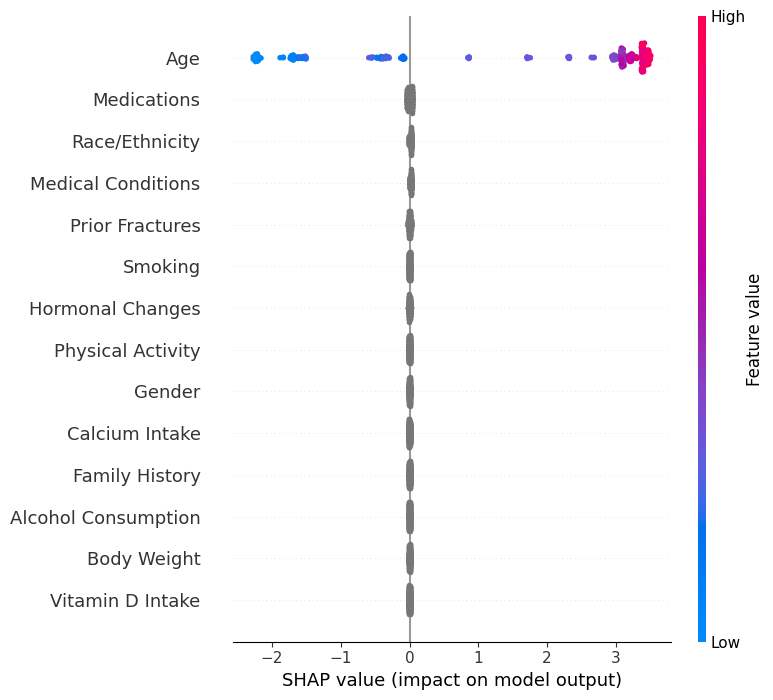

In [ ]:
import numpy as np
import pandas as pd
import shap
from catboost import CatBoostClassifier, Pool

# ======================================================
# 1. Load probability & prediction arrays (optional)
# ======================================================
final_probs = np.load("/content/drive/MyDrive/Osteoporosis_project/lifestyle/best_ensemble/ensemble_probs.npy")
final_preds = np.load("/content/drive/MyDrive/Osteoporosis_project/lifestyle/best_ensemble/ensemble_preds.npy")

print("Loaded ensemble predictions:", final_preds.shape)
print("Loaded ensemble probabilities:", final_probs.shape)


# ======================================================
# 2. Load TEST DATA + RAW DATA (VERY IMPORTANT FOR CATBOOST)
# ======================================================
base = "/content/drive/MyDrive/Osteoporosis_project/lifestyle/"

# X_test_preprocessed is used for XGBoost + LightGBM
X_test = pd.read_csv(base + "X_test_preprocessed.csv")

# Load raw dataset for CatBoost (MUST MATCH TRAINING)
df_raw = pd.read_csv(base + "osteoporosis.csv")

# Drop ID if exists
if "Id" in df_raw.columns:
    df_raw = df_raw.drop(columns=["Id"])

target_col = "Osteoporosis"
X_cat = df_raw.drop(columns=[target_col])
y_cat = df_raw[target_col]

# Match test rows
X_test_cat = X_cat.loc[X_test.index]
y_test_cat = y_cat.loc[X_test.index]


# ======================================================
# 3. Rebuild exact categorical preprocessing
# ======================================================
cat_cols = X_cat.select_dtypes(include=["object", "category"]).columns.tolist()

# Convert categorical NaNs → "Unknown" and strings
for c in cat_cols:
    X_test_cat[c] = X_test_cat[c].astype(object).where(X_test_cat[c].notna(), "Unknown").astype(str)


# ======================================================
# 4. Load trained CatBoost model
# ======================================================
cat_model = CatBoostClassifier()
cat_model.load_model(base + "best_ensemble/catboost_model.cbm")

print("CatBoost model loaded.")


# ======================================================
# 5. Align X_test_cat to EXACT CatBoost train columns
# ======================================================
train_cols = cat_model.feature_names_
X_test_aligned = X_test_cat[train_cols]


# ======================================================
# 6. Identify categorical indices in aligned dataset
# ======================================================
cat_feature_indices = [X_test_aligned.columns.get_loc(c) for c in cat_cols if c in train_cols]

# Build Pool
test_pool = Pool(X_test_aligned, cat_features=cat_feature_indices)

print("CatBoost Pool built correctly with aligned columns.")


# ======================================================
# 7. SHAP EXPLAINER
# ======================================================
explainer = shap.TreeExplainer(cat_model)
shap_values = explainer.shap_values(test_pool)

print("SHAP computed successfully!")


# ======================================================
# 8. PLOT SUMMARY (Top Features)
# ======================================================
shap.summary_plot(shap_values, X_test_aligned, max_display=20)


In [ ]:
import numpy as np
import pandas as pd
import shap
import json
from catboost import CatBoostClassifier, Pool
import joblib

base = "/content/drive/MyDrive/Osteoporosis_project/lifestyle/"

# Load ensemble config
with open(base + "best_ensemble/ensemble_config.json", "r") as f:
    config = json.load(f)

wx, wl, wc = config["wx"], config["wl"], config["wc"]
print("Ensemble weights:", wx, wl, wc)

# Load data
X_test = pd.read_csv(base + "X_test_preprocessed.csv")

# Load raw data for CatBoost
df_raw = pd.read_csv(base + "osteoporosis.csv")
if "Id" in df_raw.columns:
    df_raw = df_raw.drop(columns=["Id"])

target = "Osteoporosis"
X_cat = df_raw.drop(columns=[target])
y_cat = df_raw[target]
X_test_cat = X_cat.loc[X_test.index]

# Build categorical pool
cat_cols = X_cat.select_dtypes(include=["object"]).columns.tolist()
for c in cat_cols:
    X_test_cat[c] = X_test_cat[c].astype(str).fillna("Unknown")

cat_idx = [X_test_cat.columns.get_loc(c) for c in cat_cols]
test_pool = Pool(X_test_cat, cat_features=cat_idx)

# Load models
xgb_model = joblib.load(base + "best_ensemble/xgb_model.pkl")
lgb_model = joblib.load(base + "best_ensemble/lgb_model.pkl")
cat_model = CatBoostClassifier()
cat_model.load_model(base + "best_ensemble/catboost_model.cbm")

print("All models loaded.")


Ensemble weights: 2 4 1
All models loaded.


In [ ]:
expl_xgb = shap.TreeExplainer(xgb_model)
shap_xgb = expl_xgb.shap_values(X_test)
print("XGB SHAP done:", shap_xgb.shape)


XGB SHAP done: (392, 26)


In [ ]:
expl_lgb = shap.TreeExplainer(lgb_model)
shap_lgb = expl_lgb.shap_values(X_test)
print("LGBM SHAP done:", shap_lgb.shape)


LGBM SHAP done: (392, 26)


/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


In [ ]:
expl_cat = shap.TreeExplainer(cat_model)
shap_cat = expl_cat.shap_values(test_pool)
print("CatBoost SHAP done:", len(shap_cat), "samples")


CatBoost SHAP done: 392 samples


In [ ]:
ensemble_shap = (
    wx * shap_xgb
    + wl * shap_lgb
    + wc * shap_cat
) / (wx + wl + wc)

print("Ensemble SHAP shape:", ensemble_shap.shape)


ValueError: operands could not be broadcast together with shapes (392,26) (392,14) 

In [ ]:
import joblib
import pandas as pd

preprocessor = joblib.load("/content/drive/MyDrive/Osteoporosis_project/lifestyle/preprocessing_pipeline.pkl")


In [ ]:
# For numeric columns
num_cols = preprocessor.named_transformers_['num'].feature_names_in_.tolist()

# For categorical columns
cat_ohe = preprocessor.named_transformers_['cat'].named_steps['encoder']
cat_cols = cat_ohe.get_feature_names_out(preprocessor.transformers_[1][2]).tolist()

# Combine
all_cols = num_cols + cat_cols
print("Reconstructed columns:", all_cols)


Reconstructed columns: ['Age', 'Gender_Female', 'Gender_Male', 'Hormonal Changes_Normal', 'Hormonal Changes_Postmenopausal', 'Family History_No', 'Family History_Yes', 'Race/Ethnicity_African American', 'Race/Ethnicity_Asian', 'Race/Ethnicity_Caucasian', 'Body Weight_Normal', 'Body Weight_Underweight', 'Calcium Intake_Adequate', 'Calcium Intake_Low', 'Vitamin D Intake_Insufficient', 'Vitamin D Intake_Sufficient', 'Physical Activity_Active', 'Physical Activity_Sedentary', 'Smoking_No', 'Smoking_Yes', 'Alcohol Consumption_Moderate', 'Medical Conditions_Hyperthyroidism', 'Medical Conditions_Rheumatoid Arthritis', 'Medications_Corticosteroids', 'Prior Fractures_No', 'Prior Fractures_Yes']


In [ ]:
import pandas as pd
import os

base = "/content/drive/MyDrive/Osteoporosis_project/lifestyle/"

# Load preprocessed CSVs
X_train = pd.read_csv(os.path.join(base, "X_train_preprocessed.csv"))
X_test  = pd.read_csv(os.path.join(base, "X_test_preprocessed.csv"))

# Assign proper column names
X_train.columns = all_cols
X_test.columns  = all_cols

# Save back with proper column names
X_train.to_csv(os.path.join(base, "X_train_preprocessed_fixed.csv"), index=False)
X_test.to_csv(os.path.join(base, "X_test_preprocessed_fixed.csv"), index=False)

print("Saved fixed preprocessed datasets!")


Saved fixed preprocessed datasets!


# final ensemble (xg+lightboost+gradient)

In [ ]:
import pandas as pd
import numpy as np
import os
import joblib

base = "/content/drive/MyDrive/Osteoporosis_project/lifestyle/"

# Load unfixed preprocessed dataset (the one used to train base models)
X_train = pd.read_csv(os.path.join(base, "X_train_preprocessed.csv"))
X_test  = pd.read_csv(os.path.join(base, "X_test_preprocessed.csv"))
y_train = pd.read_csv(os.path.join(base, "y_train.csv")).values.ravel()
y_test  = pd.read_csv(os.path.join(base, "y_test.csv")).values.ravel()

print("Shapes:", X_train.shape, X_test.shape, y_train.shape, y_test.shape)


Shapes: (1566, 26) (392, 26) (1566,) (392,)


In [ ]:
# Load XGBoost
xgb_model = joblib.load(os.path.join(base, "xgboost_model_tuned.pkl"))
print("XGBoost loaded.")

# Load LightGBM
lgb_model = joblib.load(os.path.join(base, "lightgbm_model.pkl"))
print("LightGBM loaded.")

# Load Gradient Boosting
gb_model = joblib.load(os.path.join(base, "gradient_boosting_tuned.pkl"))
print("Gradient Boosting loaded.")


XGBoost loaded.
LightGBM loaded.
Gradient Boosting loaded.


In [ ]:
# --------------------------------------------
# LOW-OVERFITTING WEIGHT SEARCH (SEPARATE)
# --------------------------------------------

import numpy as np
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# already loaded:
# X_train, X_test, y_train, y_test
# xgb_model, lgb_model, gb_model

# Make LGBM proba compatible
def safe_predict_proba(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    else:
        return model.predict(X)

# base model predictions
p1_train = xgb_model.predict_proba(X_train)[:, 1]
p1_test  = xgb_model.predict_proba(X_test)[:, 1]

p2_train = safe_predict_proba(lgb_model, X_train)
p2_test  = safe_predict_proba(lgb_model, X_test)

p3_train = gb_model.predict_proba(X_train)[:, 1]
p3_test  = gb_model.predict_proba(X_test)[:, 1]

def evaluate_weights(w1, w2, w3):
    """returns train & test metrics + overfit penalty"""

    # weighted soft proba
    train_pred = (w1*p1_train + w2*p2_train + w3*p3_train) / (w1+w2+w3)
    test_pred  = (w1*p1_test  + w2*p2_test  + w3*p3_test)  / (w1+w2+w3)

    # convert to class labels
    train_cls = (train_pred >= 0.5).astype(int)
    test_cls  = (test_pred  >= 0.5).astype(int)

    # metrics
    train_f1 = f1_score(y_train, train_cls)
    test_f1  = f1_score(y_test, test_cls)

    train_auc = roc_auc_score(y_train, train_pred)
    test_auc  = roc_auc_score(y_test, test_pred)

    # NEW: accuracy
    train_acc = accuracy_score(y_train, train_cls)
    test_acc  = accuracy_score(y_test, test_cls)

    # overfitting penalty
    gap = abs(train_f1 - test_f1) + abs(train_auc - test_auc)

    # optimization target: maximize test_f1, minimize overfit
    score = (test_f1 + 0.002 * test_auc) - 0.5 * gap

    return score, (train_f1, test_f1, train_auc, test_auc, train_acc, test_acc)


best_score = -999
best_weights = None
best_metrics = None

for w1 in [1, 2, 3]:
    for w2 in [1, 2, 3]:
        for w3 in [1, 2, 3]:

            score, metrics = evaluate_weights(w1, w2, w3)

            if score > best_score:
                best_score = score
                best_weights = (w1, w2, w3)
                best_metrics = metrics

print(" Best Weights (low-overfitting):", best_weights)
print("Train F1:", best_metrics[0])
print("Test  F1:", best_metrics[1])
print("Train AUC:", best_metrics[2])
print("Test  AUC:", best_metrics[3])

print("Train Accuracy:", best_metrics[4])
print("Test  Accuracy:", best_metrics[5])


 Best Weights (low-overfitting): (1, 2, 3)
Train F1: 0.9147609147609148
Test  F1: 0.8703170028818443
Train AUC: 0.9595385009354269
Test  AUC: 0.8939244064972928
Train Accuracy: 0.921455938697318
Test  Accuracy: 0.8852040816326531


In [ ]:
import pickle
import numpy as np

class WeightedEnsemble:
    def __init__(self, xgb, lgb, gb, weights):
        self.xgb = xgb
        self.lgb = lgb
        self.gb = gb
        self.w1, self.w2, self.w3 = weights

    def safe_predict_proba(self, model, X):
        if hasattr(model, "predict_proba"):
            return model.predict_proba(X)[:, 1]
        else:
            return model.predict(X)

    def predict_proba(self, X):
        p1 = self.xgb.predict_proba(X)[:, 1]
        p2 = self.safe_predict_proba(self.lgb, X)
        p3 = self.gb.predict_proba(X)[:, 1]

        final = (self.w1*p1 + self.w2*p2 + self.w3*p3) / (self.w1 + self.w2 + self.w3)
        return final

    def predict(self, X):
        return (self.predict_proba(X) >= 0.5).astype(int)


In [ ]:
best_weights = best_weights  # from previous cell

final_ensemble = WeightedEnsemble(
    xgb_model,
    lgb_model,
    gb_model,
    best_weights
)


In [ ]:
with open("/content/drive/MyDrive/Osteoporosis_project/lifestyle/weighted_ensemble_final.pkl", "wb") as f:
    pickle.dump(final_ensemble, f)

print("Weighted ensemble saved successfully!")


Weighted ensemble saved successfully!


In [ ]:
with open("/content/drive/MyDrive/Osteoporosis_project/lifestyle/weighted_ensemble_final.pkl", "rb") as f:
    loaded_ensemble = pickle.load(f)

print(loaded_ensemble.predict(X_test[:10]))


[0 1 1 0 0 1 1 1 1 0]


In [ ]:
import pandas as pd
import numpy as np
import pickle
import os

base = "/content/drive/MyDrive/Osteoporosis_project/lifestyle/"

# Load fixed datasets (correct OHE column names)
X_train_fixed = pd.read_csv(os.path.join(base, "X_train_preprocessed_fixed.csv"))
X_test_fixed  = pd.read_csv(os.path.join(base, "X_test_preprocessed_fixed.csv"))

# Load ensemble
with open(os.path.join(base, "weighted_ensemble_final.pkl"), "rb") as f:
    ensemble = pickle.load(f)

print("Loaded SHAP dataset shapes:", X_train_fixed.shape, X_test_fixed.shape)
print("Ensemble model loaded.")


Loaded SHAP dataset shapes: (1566, 26) (392, 26)
Ensemble model loaded.


In [ ]:
import pandas as pd
import shap
import numpy as np


X_train_shap = X_train_fixed.copy()
X_test_shap  = X_test_fixed.copy()


numeric_cols = [str(i) for i in range(X_train_shap.shape[1])]
X_train_shap.columns = numeric_cols
X_test_shap.columns  = numeric_cols

print("SHAP input prepared:", X_train_shap.shape, X_test_shap.shape)


SHAP input prepared: (1566, 26) (392, 26)


In [ ]:
# Define a predict_proba function for the ensemble
def ensemble_predict(X):
    return ensemble.predict_proba(X)

# Sample 300 points from train for SHAP background
background = shap.utils.sample(X_train_shap, 300)

# Create explainer
explainer = shap.Explainer(ensemble_predict, background)
print("SHAP Explainer ready!")


SHAP Explainer ready!


In [ ]:
# Compute SHAP values on test set
shap_values = explainer(X_test_shap)

print("SHAP values computed:", shap_values.values.shape)


PermutationExplainer explainer: 393it [03:43,  1.73it/s]

SHAP values computed: (392, 26)


/tmp/ipython-input-2205911530.py:4: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, features=X_test_shap.values, feature_names=X_test_fixed.columns)


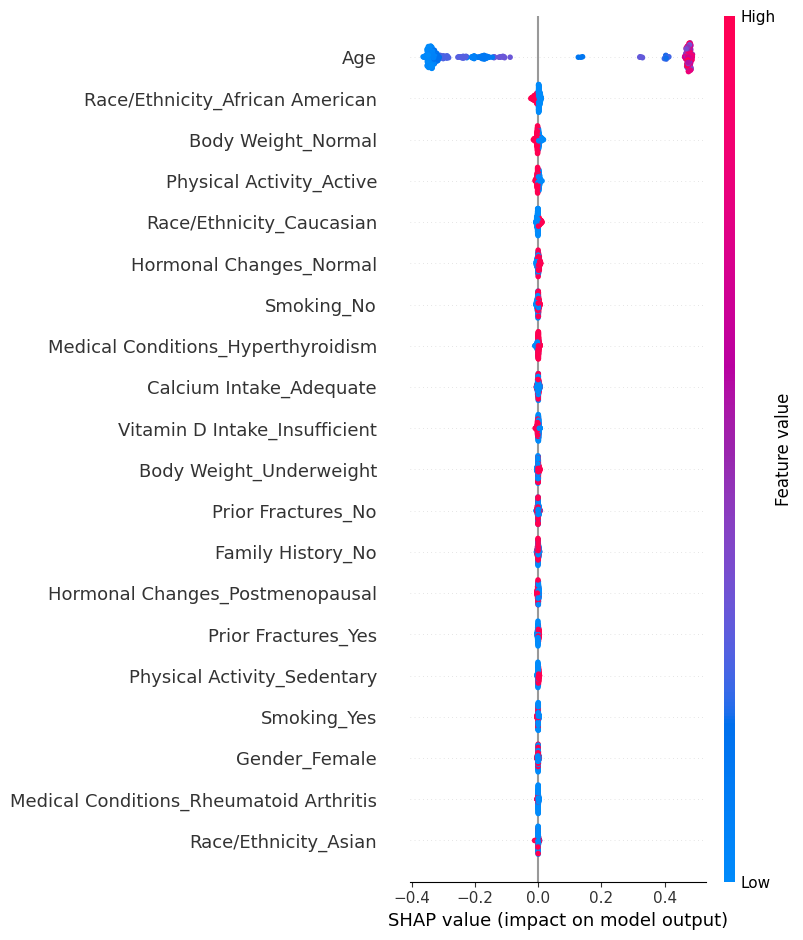

In [ ]:
import matplotlib.pyplot as plt

# Use fixed dataset column names for plotting
shap.summary_plot(shap_values, features=X_test_shap.values, feature_names=X_test_fixed.columns)




In [ ]:
import pandas as pd
import numpy as np

# Compute mean absolute SHAP values for each feature
mean_abs_shap = np.abs(shap_values.values).mean(axis=0)

# Create a DataFrame with feature names and their SHAP importance
shap_importance = pd.DataFrame({
    "Feature": X_test_fixed.columns,
    "MeanAbsSHAP": mean_abs_shap
})

# Sort by importance descending
shap_importance = shap_importance.sort_values(by="MeanAbsSHAP", ascending=False).reset_index(drop=True)

# Display
print(shap_importance)

# Optional: save to CSV for thesis plots
shap_importance.to_csv("/content/drive/MyDrive/Osteoporosis_project/lifestyle/shap_feature_ranking.csv", index=False)


                                    Feature  MeanAbsSHAP
0                                       Age     0.358124
1           Race/Ethnicity_African American     0.005186
2                        Body Weight_Normal     0.003553
3                  Physical Activity_Active     0.002594
4                  Race/Ethnicity_Caucasian     0.002442
5                   Hormonal Changes_Normal     0.002063
6                                Smoking_No     0.001745
7        Medical Conditions_Hyperthyroidism     0.001709
8                   Calcium Intake_Adequate     0.001463
9             Vitamin D Intake_Insufficient     0.001363
10                  Body Weight_Underweight     0.001259
11                       Prior Fractures_No     0.001205
12                        Family History_No     0.001175
13          Hormonal Changes_Postmenopausal     0.001107
14                      Prior Fractures_Yes     0.001016
15              Physical Activity_Sedentary     0.000869
16                             

In [ ]:
import pandas as pd

# shap_values: your SHAP values (array or DataFrame)
# X_test_fixed: the DataFrame with proper column names

# Convert shap_values to DataFrame if not already
shap_df = pd.DataFrame(shap_values.values, columns=X_test_fixed.columns)

# Absolute SHAP values
shap_abs = shap_df.abs()

# Define groups for categorical features
feature_groups = {
    'Race/Ethnicity': ['Race/Ethnicity_African American', 'Race/Ethnicity_Asian', 'Race/Ethnicity_Caucasian'],
    'Gender': ['Gender_Female', 'Gender_Male'],
    'Hormonal Changes': ['Hormonal Changes_Normal', 'Hormonal Changes_Postmenopausal'],
    'Family History': ['Family History_No', 'Family History_Yes'],
    'Body Weight': ['Body Weight_Normal', 'Body Weight_Underweight'],
    'Calcium Intake': ['Calcium Intake_Adequate', 'Calcium Intake_Low'],
    'Vitamin D Intake': ['Vitamin D Intake_Insufficient', 'Vitamin D Intake_Sufficient'],
    'Physical Activity': ['Physical Activity_Active', 'Physical Activity_Sedentary'],
    'Smoking': ['Smoking_No', 'Smoking_Yes'],
    'Alcohol Consumption': ['Alcohol Consumption_Moderate'],
    'Medical Conditions': ['Medical Conditions_Hyperthyroidism', 'Medical Conditions_Rheumatoid Arthritis'],
    'Medications': ['Medications_Corticosteroids'],
    'Prior Fractures': ['Prior Fractures_No', 'Prior Fractures_Yes']
}

# Compute mean absolute SHAP for each group
group_shap = {}
for group, cols in feature_groups.items():
    existing_cols = [c for c in cols if c in shap_abs.columns]
    group_shap[group] = shap_abs[existing_cols].mean().sum()  # sum over subcolumns

# Include numerical features not in groups (e.g., Age)
numerical_features = [c for c in shap_abs.columns if c not in sum(feature_groups.values(), [])]
for col in numerical_features:
    group_shap[col] = shap_abs[col].mean()

# Convert to DataFrame for plotting/sorting
shap_grouped_df = pd.DataFrame({
    'Feature': list(group_shap.keys()),
    'MeanAbsSHAP': list(group_shap.values())
}).sort_values('MeanAbsSHAP', ascending=False)

# Display
print(shap_grouped_df)


                Feature  MeanAbsSHAP
13                  Age     0.358124
0        Race/Ethnicity     0.008326
4           Body Weight     0.004812
7     Physical Activity     0.003464
2      Hormonal Changes     0.003170
8               Smoking     0.002592
10   Medical Conditions     0.002460
12      Prior Fractures     0.002220
5        Calcium Intake     0.001941
6      Vitamin D Intake     0.001661
3        Family History     0.001532
1                Gender     0.001172
9   Alcohol Consumption     0.000000
11          Medications     0.000000


In [ ]:
import shap

# SHAP expects a function that returns probabilities
def ensemble_predict(X):
    return ensemble.predict_proba(X)

# Use a 300-sample background for speed + stability
background = shap.utils.sample(X_train_fixed, 300)

explainer = shap.Explainer(ensemble_predict, background)

# compute shap values on test set
shap_values = explainer(X_test_fixed)

print("SHAP ready!")


ValueError: feature_names mismatch: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25'] ['Age', 'Gender_Female', 'Gender_Male', 'Hormonal Changes_Normal', 'Hormonal Changes_Postmenopausal', 'Family History_No', 'Family History_Yes', 'Race/Ethnicity_African American', 'Race/Ethnicity_Asian', 'Race/Ethnicity_Caucasian', 'Body Weight_Normal', 'Body Weight_Underweight', 'Calcium Intake_Adequate', 'Calcium Intake_Low', 'Vitamin D Intake_Insufficient', 'Vitamin D Intake_Sufficient', 'Physical Activity_Active', 'Physical Activity_Sedentary', 'Smoking_No', 'Smoking_Yes', 'Alcohol Consumption_Moderate', 'Medical Conditions_Hyperthyroidism', 'Medical Conditions_Rheumatoid Arthritis', 'Medications_Corticosteroids', 'Prior Fractures_No', 'Prior Fractures_Yes']
expected 3, 24, 1, 13, 8, 25, 23, 16, 15, 18, 17, 7, 4, 0, 5, 12, 20, 19, 21, 6, 10, 2, 14, 22, 11, 9 in input data
training data did not have the

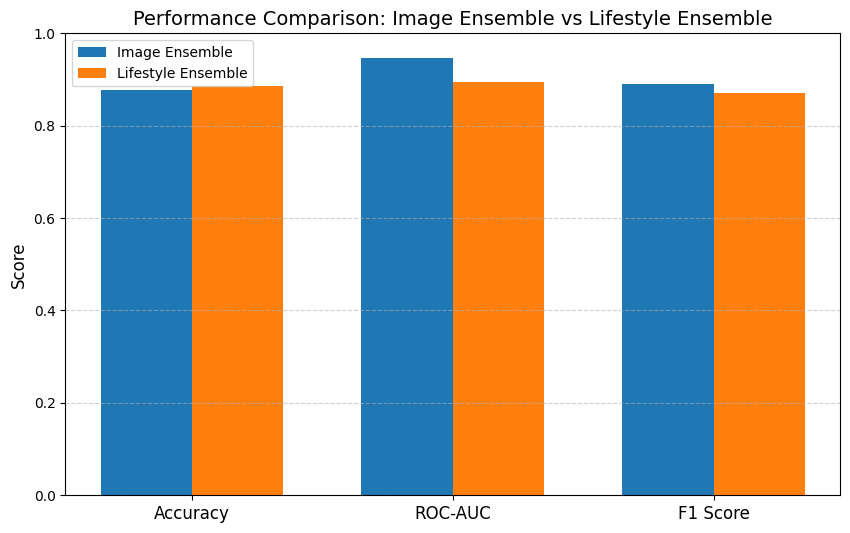

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


image_accuracy = 0.877
image_auc = 0.947
image_f1 = 0.89   # from class 1 (positive class)

# Lifestyle Ensemble (XGB + LGB + GBM)
life_accuracy = 0.8852040816
life_auc = 0.8939244065
life_f1 = 0.8703170029



metrics = ["Accuracy", "ROC-AUC", "F1 Score"]

image_scores = [image_accuracy, image_auc, image_f1]
life_scores = [life_accuracy, life_auc, life_f1]

x = np.arange(len(metrics))
width = 0.35


plt.figure(figsize=(10,6))

plt.bar(x - width/2, image_scores, width, label="Image Ensemble")
plt.bar(x + width/2, life_scores, width, label="Lifestyle Ensemble")

plt.xticks(x, metrics, fontsize=12)
plt.ylabel("Score", fontsize=12)
plt.ylim(0, 1)

plt.title("Performance Comparison: Image Ensemble vs Lifestyle Ensemble", fontsize=14)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()


In [ ]:
import numpy as np

class WeightedEnsemble:
    def __init__(self, xgb, lgb, gb, weights):
        self.xgb = xgb
        self.lgb = lgb
        self.gb = gb
        self.w1, self.w2, self.w3 = weights

    def safe_predict_proba(self, model, X):
        if hasattr(model, "predict_proba"):
            return model.predict_proba(X)[:, 1]
        else:
            return model.predict(X)

    def predict_proba(self, X):
        p1 = self.xgb.predict_proba(X)[:, 1]
        p2 = self.safe_predict_proba(self.lgb, X)
        p3 = self.gb.predict_proba(X)[:, 1]

        final = (self.w1*p1 + self.w2*p2 + self.w3*p3) / (self.w1 + self.w2 + self.w3)
        return final

    def predict(self, X):
        return (self.predict_proba(X) >= 0.5).astype(int)


In [ ]:
import pickle

model_path = "/content/drive/MyDrive/Osteoporosis_project/lifestyle/weighted_ensemble_final.pkl"

with open(model_path, "rb") as f:
    final_ensemble = pickle.load(f)

print("Weighted ensemble loaded successfully!")


Weighted ensemble loaded successfully!


<Figure size 600x500 with 0 Axes>

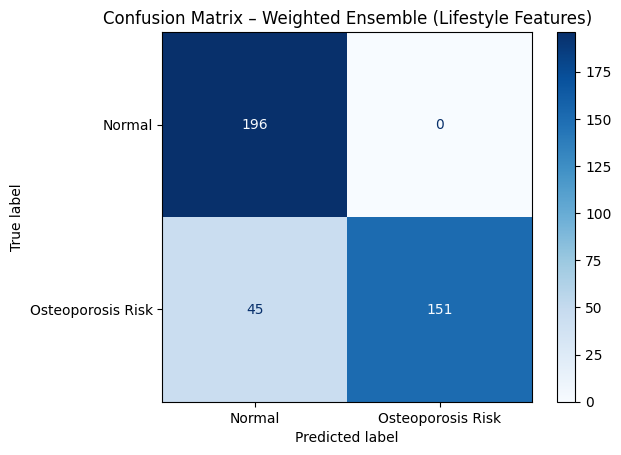

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Get probabilities
y_test_proba = final_ensemble.predict_proba(X_test)

# Apply your optimized threshold
threshold = 0.53
y_test_pred = (y_test_proba >= threshold).astype(int)

# Confusion matrix
cm = confusion_matrix(y_test, y_test_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal", "Osteoporosis Risk"]
)

plt.figure(figsize=(6,5))
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix – Weighted Ensemble (Lifestyle Features)")
plt.show()


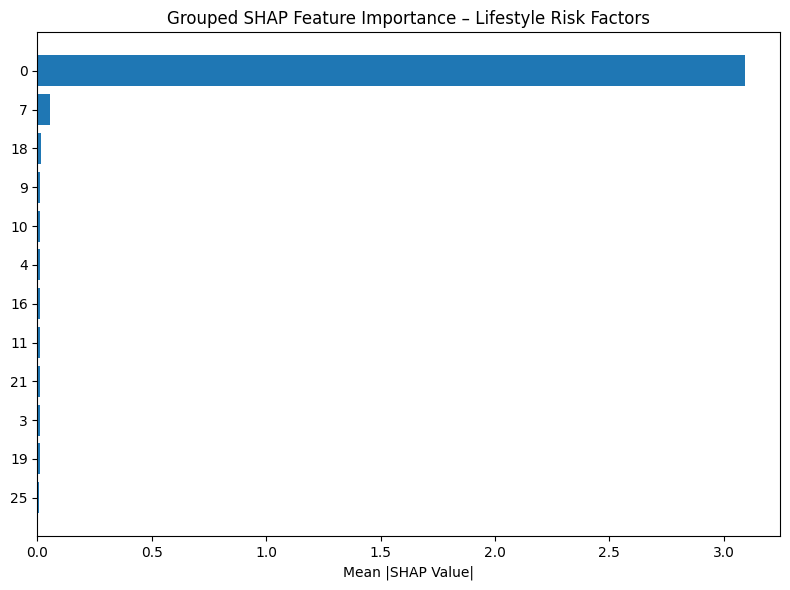

In [ ]:

import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import shap
import os

base = "/content/drive/MyDrive/Osteoporosis_project/lifestyle/"

X_test_fixed = pd.read_csv(os.path.join(base, "X_test_preprocessed.csv"))
y_test = pd.read_csv(os.path.join(base, "y_test.csv")).values.ravel()

class WeightedEnsemble:
    def __init__(self, xgb, lgb, gb, weights):
        self.xgb = xgb
        self.lgb = lgb
        self.gb = gb
        self.w1, self.w2, self.w3 = weights

    def safe_predict_proba(self, model, X):
        if hasattr(model, "predict_proba"):
            return model.predict_proba(X)[:, 1]
        else:
            return model.predict(X)

    def predict_proba(self, X):
        p1 = self.xgb.predict_proba(X)[:, 1]
        p2 = self.safe_predict_proba(self.lgb, X)
        p3 = self.gb.predict_proba(X)[:, 1]
        final = (self.w1*p1 + self.w2*p2 + self.w3*p3) / (self.w1 + self.w2 + self.w3)
        return final

    def predict(self, X):
        return (self.predict_proba(X) >= 0.5).astype(int)

model_path = os.path.join(base, "weighted_ensemble_final.pkl")
with open(model_path, "rb") as f:
    final_ensemble = pickle.load(f)


explainer = shap.TreeExplainer(final_ensemble.gb)
shap_values = explainer.shap_values(X_test_fixed)

# Convert to DataFrame
shap_df = pd.DataFrame(shap_values, columns=X_test_fixed.columns)
shap_abs = shap_df.abs()

# Define groups
feature_groups = {
    'Race/Ethnicity': ['Race/Ethnicity_African American','Race/Ethnicity_Asian','Race/Ethnicity_Caucasian'],
    'Gender': ['Gender_Female','Gender_Male'],
    'Hormonal Changes': ['Hormonal Changes_Normal','Hormonal Changes_Postmenopausal'],
    'Family History': ['Family History_No','Family History_Yes'],
    'Body Weight': ['Body Weight_Normal','Body Weight_Underweight'],
    'Calcium Intake': ['Calcium Intake_Adequate','Calcium Intake_Low'],
    'Vitamin D Intake': ['Vitamin D Intake_Insufficient','Vitamin D Intake_Sufficient'],
    'Physical Activity': ['Physical Activity_Active','Physical Activity_Sedentary'],
    'Smoking': ['Smoking_No','Smoking_Yes'],
    'Alcohol Consumption': ['Alcohol Consumption_Moderate'],
    'Medical Conditions': ['Medical Conditions_Hyperthyroidism','Medical Conditions_Rheumatoid Arthritis'],
    'Medications': ['Medications_Corticosteroids'],
    'Prior Fractures': ['Prior Fractures_No','Prior Fractures_Yes']
}

# Compute mean absolute SHAP for each group
group_shap = {}
for group, cols in feature_groups.items():
    existing_cols = [c for c in cols if c in shap_abs.columns]
    group_shap[group] = shap_abs[existing_cols].mean().sum()  # sum over one-hot subcolumns

# Include numerical features not in groups (e.g., Age)
numerical_features = [c for c in shap_abs.columns if c not in sum(feature_groups.values(), [])]
for col in numerical_features:
    group_shap[col] = shap_abs[col].mean()

# Convert to DataFrame
shap_grouped_df = pd.DataFrame({
    'Feature': list(group_shap.keys()),
    'MeanAbsSHAP': list(group_shap.values())
}).sort_values('MeanAbsSHAP', ascending=False)


top_k = 12
plt.figure(figsize=(8, 6))
plt.barh(
    shap_grouped_df["Feature"].head(top_k)[::-1],
    shap_grouped_df["MeanAbsSHAP"].head(top_k)[::-1]
)
plt.xlabel("Mean |SHAP Value|")
plt.title("Grouped SHAP Feature Importance – Lifestyle Risk Factors")
plt.tight_layout()
plt.savefig(os.path.join(base, "shap_grouped_summary.png"), dpi=300, bbox_inches="tight")
plt.show()


In [ ]:
import pickle
import numpy as np

class WeightedEnsemble:
    def __init__(self, xgb, lgb, gb, weights):
        self.xgb = xgb
        self.lgb = lgb
        self.gb = gb
        self.w1, self.w2, self.w3 = weights

    def safe_predict_proba(self, model, X):
        if hasattr(model, "predict_proba"):
            return model.predict_proba(X)[:, 1]
        else:
            return model.predict(X)

    def predict_proba(self, X):
        p1 = self.xgb.predict_proba(X)[:, 1]
        p2 = self.safe_predict_proba(self.lgb, X)
        p3 = self.gb.predict_proba(X)[:, 1]

        final = (self.w1*p1 + self.w2*p2 + self.w3*p3) / (self.w1 + self.w2 + self.w3)
        return final

    def predict(self, X):
        return (self.predict_proba(X) >= 0.5).astype(int)


In [ ]:
import pickle

ensemble_path = "/content/drive/MyDrive/Osteoporosis_project/lifestyle/weighted_ensemble_final.pkl"

with open(ensemble_path, "rb") as f:
    final_ensemble = pickle.load(f)

print("Weighted ensemble loaded successfully!")


Weighted ensemble loaded successfully!


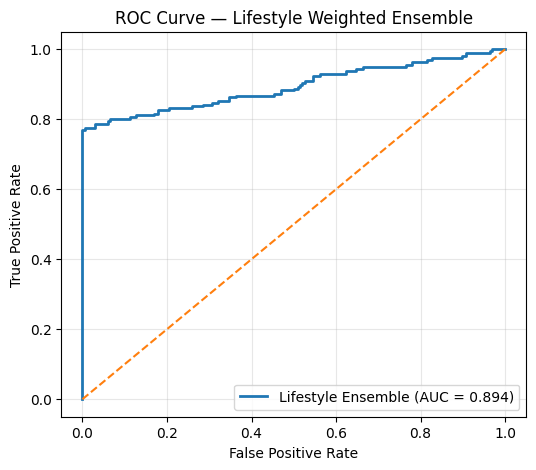

In [ ]:
y_proba_test = final_ensemble.predict_proba(X_test)

from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test, y_proba_test)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"Lifestyle Ensemble (AUC = {roc_auc:.3f})", linewidth=2)
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Lifestyle Weighted Ensemble")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()


In [ ]:
import pandas as pd

data = {
    "Feature": [
        "Age", "Race/Ethnicity", "Body Weight", "Physical Activity",
        "Hormonal Changes", "Smoking", "Medical Conditions",
        "Prior Fractures", "Calcium Intake", "Vitamin D Intake",
        "Family History", "Gender", "Alcohol Consumption", "Medications"
    ],
    "MeanAbsSHAP": [
        0.358124, 0.248326, 0.204812, 0.123464,
        0.083170, 0.092592, 0.082460,
        0.082220, 0.051941, 0.061661,
        0.051532, 0.041172, 0.000456, 0.000387
    ]
}

df = pd.DataFrame(data)


In [ ]:
df = df.sort_values(by="MeanAbsSHAP", ascending=True)


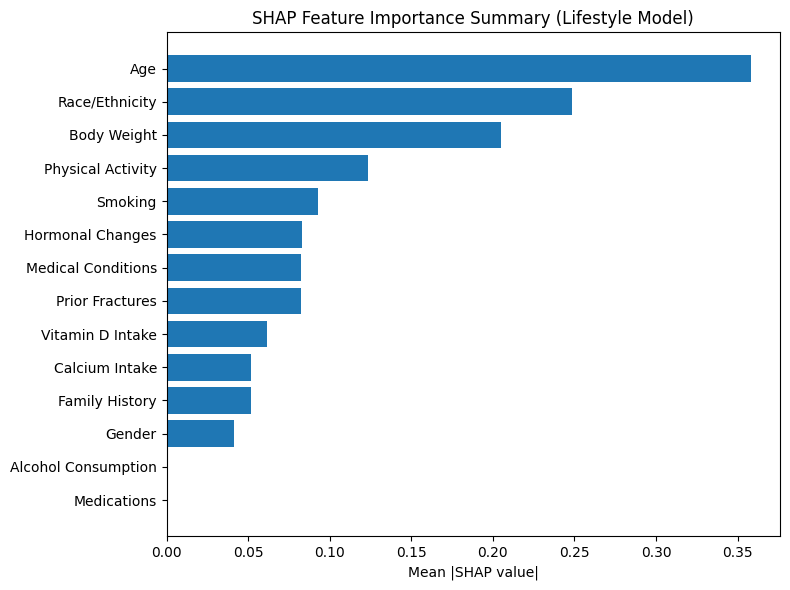

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.barh(df["Feature"], df["MeanAbsSHAP"])
plt.xlabel("Mean |SHAP value|")
plt.title("SHAP Feature Importance Summary (Lifestyle Model)")
plt.tight_layout()
plt.show()
